In [ ]:
# Inspect CEPII bilateral features and missingness
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cepii_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")

# Keep as many non-binary bilateral features as possible
feature_cols = [
    "distw_harmonic",
    "distw_arithmetic",
    "dist",
    "distcap",
    "diplo_disagreement",
    "scaled_sci_2021",
    "comrelig",
    "col_dep_end_year",
    "sever_year",
    "rta_coverage",
    "rta_type",
    "tradeflow_comtrade_o",
    "tradeflow_comtrade_d",
    "tradeflow_baci",
    "manuf_tradeflow_baci",
    "tradeflow_imf_o",
    "tradeflow_imf_d",
]

cepii = pd.read_csv(
    cepii_path,
    usecols=["year", "iso3_o", "iso3_d"] + feature_cols,
)

print("Rows:", len(cepii))
print("Years:", sorted(cepii["year"].dropna().unique().tolist()))
print("Columns:", cepii.columns.tolist())

# 1) overall feature coverage
coverage = pd.DataFrame({
    "non_null": cepii[feature_cols].notna().sum(),
    "coverage_share": cepii[feature_cols].notna().mean(),
    "n_unique": cepii[feature_cols].nunique(dropna=True),
    "min": cepii[feature_cols].min(numeric_only=False),
    "max": cepii[feature_cols].max(numeric_only=False),
}).sort_values("coverage_share", ascending=False)

display(coverage)

# 2) coverage by year
coverage_by_year = (
    cepii.groupby("year")[feature_cols]
    .apply(lambda x: x.notna().mean())
    .T
)

plt.figure(figsize=(12, 6))
plt.imshow(coverage_by_year.values, aspect="auto", cmap="viridis")
plt.colorbar(label="non-missing share")
plt.xticks(range(len(coverage_by_year.columns)), coverage_by_year.columns)
plt.yticks(range(len(coverage_by_year.index)), coverage_by_year.index)
plt.title("CEPII feature coverage by year")
plt.tight_layout()
plt.show()

display(coverage_by_year)

# 3) country-level missingness:
# for each ISO3, how many outgoing/incoming corridors have each feature available?
outgoing_country_coverage = (
    cepii.groupby("iso3_o")[feature_cols]
    .apply(lambda x: x.notna().mean())
    .sort_index()
)

incoming_country_coverage = (
    cepii.groupby("iso3_d")[feature_cols]
    .apply(lambda x: x.notna().mean())
    .sort_index()
)

# average across features, useful to spot countries with poor bilateral coverage
outgoing_summary = outgoing_country_coverage.mean(axis=1).sort_values()
incoming_summary = incoming_country_coverage.mean(axis=1).sort_values()

print("\nWorst outgoing coverage:")
display(outgoing_summary.head(20).rename("mean_feature_coverage").to_frame())

print("\nWorst incoming coverage:")
display(incoming_summary.head(20).rename("mean_feature_coverage").to_frame())

# 4) optional: inspect one country
inspect_iso3 = "IND"   # change this
country_view = cepii[(cepii["iso3_o"] == inspect_iso3) | (cepii["iso3_d"] == inspect_iso3)].copy()

print(f"\nRows involving {inspect_iso3}: {len(country_view)}")

country_feature_coverage = pd.DataFrame({
    "non_null": country_view[feature_cols].notna().sum(),
    "coverage_share": country_view[feature_cols].notna().mean(),
}).sort_values("coverage_share", ascending=False)

display(country_feature_coverage)

# 5) optional: build a "best available Sigma input" table
# idea: keep all rows, and count how many bilateral features are available on each corridor
cepii["n_available_features"] = cepii[feature_cols].notna().sum(axis=1)

best_corridors = cepii.sort_values(
    ["n_available_features", "year"],
    ascending=[False, False]
)

display(best_corridors.head(20))


In [33]:
# Temporary patch for predicted_flows_from_probabilities bug in src.ferm.model
import numpy as np
import pandas as pd

import src.ferm.model as ferm_model
from src.ferm.model import add_error_columns
from src.ferm.utils import code_to_country


def predicted_flows_from_probabilities_safe(
    flows,
    P,
    nodes=None,
    origin_col="country_from",
    dest_col="country_to",
    flow_col="num_migrants",
    pred_col="predicted_migrants",
    eps=1.0,
):
    outflow = flows.groupby(origin_col)[flow_col].sum()
    total_outflow = outflow.reindex(P.index).fillna(0.0).to_numpy()

    predicted_matrix = total_outflow[:, None] * P.to_numpy()

    # Important: force independent index/column objects
    pred_index = pd.Index(P.index.tolist(), name=origin_col)
    pred_columns = pd.Index(P.columns.tolist(), name=dest_col)

    predicted = pd.DataFrame(
        predicted_matrix,
        index=pred_index,
        columns=pred_columns,
    )

    predicted = predicted.stack().reset_index(name=pred_col)
    predicted = predicted[predicted[origin_col] != predicted[dest_col]].copy()

    comparison = flows.merge(predicted, on=[origin_col, dest_col], how="outer")

    if nodes is not None and {"code", "country_name"}.issubset(nodes.columns):
        name_map = nodes.set_index("code")["country_name"].to_dict()
        comparison["country_from_name"] = (
            comparison[origin_col]
            .map(name_map)
            .fillna(comparison[origin_col].map(code_to_country))
        )
        comparison["country_to_name"] = (
            comparison[dest_col]
            .map(name_map)
            .fillna(comparison[dest_col].map(code_to_country))
        )
    else:
        comparison["country_from_name"] = comparison[origin_col].map(code_to_country)
        comparison["country_to_name"] = comparison[dest_col].map(code_to_country)

    comparison[flow_col] = comparison[flow_col].fillna(0.0)
    comparison[pred_col] = comparison[pred_col].fillna(0.0)

    comparison = add_error_columns(
        comparison=comparison,
        observed_col=flow_col,
        predicted_col=pred_col,
        eps=eps,
    )

    return comparison


ferm_model.predicted_flows_from_probabilities = predicted_flows_from_probabilities_safe
print("Patched src.ferm.model.predicted_flows_from_probabilities")


Patched src.ferm.model.predicted_flows_from_probabilities


In [48]:
# Relational FERM calibration on validation_2019_h1, then evaluation on test_2019_h2
# Uses the note-aligned FERM class directly: FERM(nodes, flows, features=Sigma).


import numpy as np
import pandas as pd

import importlib
import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM
from src.ferm.config import Config
from src.ferm.preprocessing import filter_flows_by_continent, split_flows_by_period
from src.ferm.utils import (
    add_niche,
    build_master_country_table,
    load_country_geometries_global,
    load_migration_data,
    load_niche_data,
    load_population_data,
    prepare_nodes,
)


def rescale_relational_feature(values, direction="positive"):
    """
    Rescale one bilateral feature to [-1, 1] so 0 remains neutral.
    """
    x = pd.to_numeric(values, errors="coerce")
    out = pd.Series(np.nan, index=x.index, dtype=float)

    valid = x.notna()
    if valid.sum() == 0:
        return out

    x_valid = x[valid]
    xmin = x_valid.min()
    xmax = x_valid.max()

    if pd.isna(xmin) or pd.isna(xmax) or xmin == xmax:
        out.loc[valid] = 0.0
        return out

    scaled = 2.0 * (x - xmin) / (xmax - xmin) - 1.0

    if direction == "positive":
        out.loc[valid] = scaled.loc[valid]
    elif direction == "negative":
        out.loc[valid] = -scaled.loc[valid]
    else:
        raise ValueError("direction must be 'positive' or 'negative'")

    return out


def build_relational_feature_table(nodes, gravity_pairs, feature_col, direction):
    code_lookup = nodes[["code", "iso3"]].dropna().drop_duplicates().copy()
    code_lookup["iso3"] = code_lookup["iso3"].astype(str).str.strip().str.upper()

    tmp = gravity_pairs[["iso3_o", "iso3_d", feature_col]].copy()
    tmp["iso3_o"] = tmp["iso3_o"].astype(str).str.strip().str.upper()
    tmp["iso3_d"] = tmp["iso3_d"].astype(str).str.strip().str.upper()

    tmp = tmp.merge(
        code_lookup.rename(columns={"code": "country_from", "iso3": "origin_iso3"}),
        left_on="iso3_o",
        right_on="origin_iso3",
        how="inner",
    )
    tmp = tmp.merge(
        code_lookup.rename(columns={"code": "country_to", "iso3": "destination_iso3"}),
        left_on="iso3_d",
        right_on="destination_iso3",
        how="inner",
    )

    tmp = tmp[tmp["origin_iso3"] != tmp["destination_iso3"]].copy()
    tmp["Sigma_ij"] = rescale_relational_feature(tmp[feature_col], direction)
    tmp = tmp.dropna(subset=["Sigma_ij"]).copy()

    return tmp[
        ["country_from", "country_to", "origin_iso3", "destination_iso3", feature_col, "Sigma_ij"]
    ].drop_duplicates(["origin_iso3", "destination_iso3"])


def build_relational_sigma(nodes, corridor_features, value_col="Sigma_ij", fill_value=0.0):
    """
    Build the relational-FERM Sigma matrix: rows are origins, columns are destinations,
    diagonal is neutral, and off-diagonal entries are corridor effects.
    """
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    values = np.full((len(codes), len(codes)), float(fill_value), dtype=float)
    np.fill_diagonal(values, 0.0)
    Sigma = pd.DataFrame(values, index=codes, columns=codes)

    for row in corridor_features.itertuples(index=False):
        origin = getattr(row, "origin_iso3")
        destination = getattr(row, "destination_iso3")
        if origin in Sigma.index and destination in Sigma.columns and origin != destination:
            Sigma.loc[origin, destination] = float(getattr(row, value_col))

    return Sigma


def build_abel_sigma(
    nodes: pd.DataFrame,
    abel_path: str | Path = "abel-database-s2.xlsx",
    sheet_name: str = "2005-10",
    normalize_by: str = "destination",
    transform: str = "column_log_zscore_clipped",
    fill_value: float = 0.0,
) -> pd.DataFrame:
    """
    Build a Sigma matrix from Abel bilateral migration stocks.

    Abel rows are origins and columns are destinations. The default normalization
    divides each stock from origin i to destination j by destination population,
    making Sigma[i, j] a destination-population-normalized migrant-stock intensity.
    The off-diagonal values are then log-compressed, column-wise z-scored, and clipped so
    each destination has its own neutral baseline and negative values are possible.
    """
    raw = pd.read_excel(abel_path, sheet_name=sheet_name, header=None)

    destination_codes = raw.iloc[2, 3:-1].astype(str).str.strip().str.upper().tolist()
    matrix = raw.iloc[3:, 3:-1].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    origin_codes = raw.iloc[3:, 2].astype(str).str.strip().str.upper().tolist()
    abel = pd.DataFrame(matrix.to_numpy(dtype=float), index=origin_codes, columns=destination_codes)
    abel = abel.groupby(level=0).sum()
    abel = abel.T.groupby(level=0).sum().T

    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    stocks = abel.reindex(index=codes, columns=codes).fillna(float(fill_value))

    populations = nodes.set_index("iso3")["population"].astype(float)
    populations.index = populations.index.astype(str).str.strip().str.upper()
    populations = populations.reindex(codes).replace(0.0, np.nan)

    if normalize_by == "destination":
        normalized = stocks.div(populations, axis="columns")
    elif normalize_by == "origin":
        normalized = stocks.div(populations, axis="index")
    else:
        raise ValueError("normalize_by must be 'destination' or 'origin'.")

    normalized = normalized.replace([np.inf, -np.inf], np.nan).fillna(float(fill_value))
    values = normalized.to_numpy(dtype=float, copy=True)
    off_diag = ~np.eye(len(codes), dtype=bool)

    if transform == "log_zscore":
        values = np.log1p(values)
        reference = values[off_diag]
        center = np.nanmean(reference)
        scale = np.nanstd(reference)
        values = (values - center) / scale if scale > 0 else values - center
    elif transform == "row_log_zscore":
        values = np.log1p(values)
        for row_idx in range(len(codes)):
            row_mask = np.ones(len(codes), dtype=bool)
            row_mask[row_idx] = False
            reference = values[row_idx, row_mask]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[row_idx, :] = (values[row_idx, :] - center) / scale
            else:
                values[row_idx, :] = values[row_idx, :] - center
    elif transform == "column_log_zscore":
        values = np.log1p(values)
        for col_idx in range(len(codes)):
            col_mask = np.ones(len(codes), dtype=bool)
            col_mask[col_idx] = False
            reference = values[col_mask, col_idx]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[:, col_idx] = (values[:, col_idx] - center) / scale
            else:
                values[:, col_idx] = values[:, col_idx] - center
    elif transform == "column_log_zscore_clipped":
        values = np.log1p(values)
        for col_idx in range(len(codes)):
            col_mask = np.ones(len(codes), dtype=bool)
            col_mask[col_idx] = False
            reference = values[col_mask, col_idx]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[:, col_idx] = (values[:, col_idx] - center) / scale
            else:
                values[:, col_idx] = values[:, col_idx] - center
        values = np.clip(values, -1.0, 1.0)
    elif transform == "zscore":
        reference = values[off_diag]
        center = np.nanmean(reference)
        scale = np.nanstd(reference)
        values = (values - center) / scale if scale > 0 else values - center
    elif transform == "minmax_centered":
        reference = values[off_diag]
        min_value = np.nanmin(reference)
        max_value = np.nanmax(reference)
        if max_value > min_value:
            values = 2.0 * (values - min_value) / (max_value - min_value) - 1.0
        else:
            values = np.zeros_like(values)
    else:
        raise ValueError("transform must be 'log_zscore', 'row_log_zscore', 'column_log_zscore', 'column_log_zscore_clipped', 'zscore', or 'minmax_centered'.")

    values = np.nan_to_num(values, nan=float(fill_value), posinf=float(fill_value), neginf=float(fill_value))
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=codes, columns=codes)


def build_gravity_distance_matrix(
    nodes: pd.DataFrame,
    gravity_pairs: pd.DataFrame,
    distance_col: str = "dist",
) -> pd.DataFrame:
    """
    Build an ISO3-by-ISO3 distance matrix from CEPII Gravity distances.
    Rows are origins and columns are destinations.
    """
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    scoped = gravity_pairs[["iso3_o", "iso3_d", distance_col]].copy()
    scoped["iso3_o"] = scoped["iso3_o"].astype(str).str.strip().str.upper()
    scoped["iso3_d"] = scoped["iso3_d"].astype(str).str.strip().str.upper()
    scoped[distance_col] = pd.to_numeric(scoped[distance_col], errors="coerce")

    pivot = scoped.pivot_table(
        index="iso3_o",
        columns="iso3_d",
        values=distance_col,
        aggfunc="mean",
    )
    distances = pivot.reindex(index=codes, columns=codes)
    distances = distances.combine_first(distances.T)

    values = distances.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(values, 0.0)
    distances = pd.DataFrame(values, index=codes, columns=codes)

    if distances.isna().any().any():
        missing = [
            (origin, destination)
            for origin in distances.index
            for destination in distances.columns
            if pd.isna(distances.loc[origin, destination])
        ]
        raise ValueError(
            f"CEPII `{distance_col}` is missing {len(missing)} node-pair distances; "
            f"first missing pairs: {missing[:10]}"
        )

    return distances


def summarize_comp(comp, observed_col="num_migrants"):
    obs = pd.to_numeric(comp[observed_col], errors="coerce")
    pred = pd.to_numeric(comp["predicted_migrants"], errors="coerce")

    out = {
        "pairs": len(comp),
        "observed_total": obs.sum(),
        "predicted_total": pred.sum(),
        "MAE": np.mean(np.abs(pred - obs)),
        "RMSE": np.sqrt(np.mean((pred - obs) ** 2)),
        "obs_std": obs.std(),
        "pred_std": pred.std(),
        "obs_unique": obs.nunique(),
        "pred_unique": pred.nunique(),
    }

    if obs.nunique() > 1 and pred.nunique() > 1 and obs.std() > 0 and pred.std() > 0:
        out["Pearson"] = obs.corr(pred, method="pearson")
        out["Spearman"] = obs.corr(pred, method="spearman")
        out["Pearson_log"] = np.log10(obs + 1).corr(np.log10(pred + 1), method="pearson")
        out["Spearman_log"] = np.log10(obs + 1).corr(np.log10(pred + 1), method="spearman")
    else:
        out["Pearson"] = np.nan
        out["Spearman"] = np.nan
        out["Pearson_log"] = np.nan
        out["Spearman_log"] = np.nan

    out["Median_abs_log_ratio"] = np.median(
        np.abs(np.log10((pred + 1) / (obs + 1)))
    )

    return out


In [49]:
# ----------------------------
# prepare base data if this cell is run standalone
# ----------------------------
if "pair_lookup" not in globals() or "country" not in globals():
    config = Config(
        niche_method="zscore_log",
        niche_type="gdp_per_capita_2018",
        target_continent="Asia",
        num_particles=100000,
        sigma=5.0,
        verbose=True,
    )

    migrations = load_migration_data(config.flow_path)
    populations = load_population_data(config.pop_path)
    world_gdf, country_geo = load_country_geometries_global()
    niche_df = load_niche_data(config.gdp_path, niche_type=config.niche_type)

    master_country = build_master_country_table(
        country_geo,
        populations,
        niche_df=niche_df,
        niche_col=config.niche_type,
    )
    flows, country = filter_flows_by_continent(
        master_country,
        migrations,
        niche_type=config.niche_type,
        continent=config.target_continent,
    )
    pair_lookup = split_flows_by_period(flows, master_country)
    country = add_niche(
        country,
        niche_col=config.niche_type,
        method=config.niche_method,
    )

# ----------------------------
# choose one feature to calibrate
# ----------------------------
use_abel_sigma = True
abel_sheet_name = "2005-10"
relational_feature_year = 2019
relational_feature = "comrelig"
relational_direction = "positive"
# relational_feature = "dist"; relational_direction = "negative"
# relational_feature = "diplo_disagreement"; relational_direction = "negative"

# ----------------------------
# choose calibration grids
# ----------------------------
sigma_grid = [0.1, 0.5, 1.0, 2.0, 5.0]
particles_grid = [10000, 50000, 100000]

# ----------------------------
# load CEPII feature
# ----------------------------
distance_col = "dist"
gravity_pairs = pd.read_csv(
    "Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv",
    usecols=["year", "iso3_o", "iso3_d", relational_feature, distance_col],
)
gravity_pairs = gravity_pairs[gravity_pairs["year"] == relational_feature_year].copy()

# ----------------------------
# get validation and test flows
# assumes these already exist from your notebook pipeline:
# pair_lookup, country, prepare_nodes
# ----------------------------
flows_val = pair_lookup["validation_2019_h1"].rename({"total_migrants": "num_migrants"}, axis=1).copy()
flows_test = pair_lookup["test_2019_h2"].rename({"total_migrants": "num_migrants"}, axis=1).copy()

nodes_val = prepare_nodes(country, flows_val)
nodes_test = prepare_nodes(country, flows_test)

rel_pairs_val = build_relational_feature_table(
    nodes_val, gravity_pairs, relational_feature, relational_direction
)
rel_pairs_test = build_relational_feature_table(
    nodes_test, gravity_pairs, relational_feature, relational_direction
)


# Optional Abel Sigma matrices, if you want this calibration cell to use Abel stocks
# instead of one CEPII bilateral feature.
Sigma_val_relational = build_relational_sigma(nodes_val, rel_pairs_val)
Sigma_test_relational = build_relational_sigma(nodes_test, rel_pairs_test)
Sigma_val_abel = build_abel_sigma(nodes_val, sheet_name=abel_sheet_name, normalize_by="destination", transform="column_log_zscore_clipped")
Sigma_test_abel = build_abel_sigma(nodes_test, sheet_name=abel_sheet_name, normalize_by="destination", transform="column_log_zscore_clipped")

Sigma_val = Sigma_val_abel if use_abel_sigma else Sigma_val_relational
Sigma_test = Sigma_test_abel if use_abel_sigma else Sigma_test_relational
sigma_feature_label = "abel_stock" if use_abel_sigma else relational_feature

D_val = build_gravity_distance_matrix(nodes_val, gravity_pairs, distance_col=distance_col)
D_test = build_gravity_distance_matrix(nodes_test, gravity_pairs, distance_col=distance_col)

# ----------------------------
# calibration loop
# ----------------------------
rows = []

for sigma in sigma_grid:
    for num_particles in particles_grid:
        model = FERM(
            nodes=nodes_val,
            flows=flows_val,
            features=Sigma_val,
            distance_matrix=D_val,
        )

        result = model.run(
            num_particles=num_particles,
            sigma=sigma,
            verbose=False,
        )

        metrics = summarize_comp(result.comparison, observed_col="num_migrants")
        metrics.update({
            "feature": sigma_feature_label,
            "sigma": sigma,
            "num_particles": num_particles,
        })
        rows.append(metrics)

calib_df = pd.DataFrame(rows)
calib_df = calib_df.sort_values(
    ["Pearson_log", "Median_abs_log_ratio"],
    ascending=[False, True],
).reset_index(drop=True)

display(calib_df.head(20))

best_params = calib_df.iloc[0][["sigma", "num_particles"]].to_dict()

print("Best parameters:")
print(best_params)

# ----------------------------
# evaluate on test set
# ----------------------------
best_model = FERM(
    nodes=nodes_test,
    flows=flows_test,
    features=Sigma_test,
    distance_matrix=D_test,
)

best_result = best_model.run(
    num_particles=int(best_params["num_particles"]),
    sigma=float(best_params["sigma"]),
    verbose=False,
)

comp_test_rel = best_result.comparison.copy()
summary_test_rel = summarize_comp(comp_test_rel, observed_col="num_migrants")

print("\nTest summary:")
display(pd.DataFrame([summary_test_rel]))


,pairs,observed_total,predicted_total,MAE,RMSE,obs_std,pred_std,obs_unique,pred_unique,Pearson,Spearman,Pearson_log,Spearman_log,Median_abs_log_ratio,feature,sigma,num_particles
0,2070,5751056.0,5751056.0,4511.861473,25848.876463,12990.969708,24906.325085,836,837,0.186370,0.379097,0.456173,0.379097,1.380211,abel_stock,5.0,100000
1,2070,5751056.0,5751056.0,4512.647290,25849.889754,12990.969708,24908.562357,836,698,0.186445,0.359062,0.447736,0.359062,1.397940,abel_stock,5.0,50000
2,2070,5751056.0,5751056.0,4510.242895,25831.664282,12990.969708,24886.208873,836,496,0.186348,0.337985,0.427530,0.337985,1.431364,abel_stock,5.0,10000
3,2070,5751056.0,5751056.0,4765.609102,28368.222233,12990.969708,27201.328654,836,610,0.146492,0.175054,0.316110,0.175054,1.471359,abel_stock,2.0,100000
4,2070,5751056.0,5751056.0,4765.711605,28375.585734,12990.969708,27209.219526,836,540,0.146466,0.188899,0.314658,0.188899,1.476540,abel_stock,2.0,50000
5,2070,5751056.0,5751056.0,4766.938439,28422.402446,12990.969708,27260.643669,836,396,0.146388,0.212705,0.309034,0.212705,1.505150,abel_stock,2.0,10000
6,2070,5751056.0,5751056.0,4930.829977,29993.960331,12990.969708,28665.218255,836,356,0.121362,0.168561,0.263189,0.168561,1.556303,abel_stock,1.0,10000
7,2070,5751056.0,5751056.0,4929.730582,30015.241211,12990.969708,28686.080808,836,539,0.121165,0.125454,0.262935,0.125454,1.531479,abel_stock,1.0,100000
8,2070,5751056.0,5751056.0,4930.200435,30023.952848,12990.969708,28694.175867,836,481,0.121052,0.133872,0.258163,0.133872,1.531479,abel_stock,1.0,50000
9,2070,5751056.0,5751056.0,4979.049173,30722.354255,12990.969708,29395.895191,836,450,0.115958,0.085328,0.219999,0.085328,1.556303,abel_stock,0.5,50000


Best parameters:
{'sigma': 5.0, 'num_particles': 100000}

Test summary:


,pairs,observed_total,predicted_total,MAE,RMSE,obs_std,pred_std,obs_unique,pred_unique,Pearson,Spearman,Pearson_log,Spearman_log,Median_abs_log_ratio
0,2070,6186048.0,6186048.0,4906.745872,27863.739437,14409.094032,26566.634862,833,828,0.17848,0.362608,0.444117,0.362608,1.380211


Best runs by Pearson_log:


,pairs,observed_total,predicted_total,MAE,RMSE,obs_std,pred_std,obs_unique,pred_unique,Pearson,Spearman,Pearson_log,Spearman_log,Median_abs_log_ratio,feature,sigma,num_particles
0,2070,5751056.0,5751056.0,4053.747512,19338.834151,12990.969708,17010.266426,836,1090,0.189934,0.547752,0.592985,0.547752,1.176091,abel_stock,5.0,100000
1,2070,5751056.0,5751056.0,4047.974883,19291.496740,12990.969708,16963.727313,836,975,0.191019,0.537451,0.590136,0.537451,1.173363,abel_stock,5.0,50000
2,2070,5751056.0,5751056.0,4058.443745,19294.286353,12990.969708,16951.206595,836,707,0.189951,0.518376,0.577317,0.518376,1.230449,abel_stock,5.0,10000
3,2070,5751056.0,5751056.0,4188.766159,21626.421572,12990.969708,19780.329079,836,890,0.179204,0.488196,0.560411,0.488196,1.262891,abel_stock,2.0,100000
4,2070,5751056.0,5751056.0,4189.790069,21641.847159,12990.969708,19806.144527,836,799,0.179659,0.495713,0.559222,0.495713,1.278754,abel_stock,2.0,50000
5,2070,5751056.0,5751056.0,4191.469211,21636.107884,12990.969708,19785.949084,836,582,0.178770,0.481104,0.547089,0.481104,1.318056,abel_stock,2.0,10000
6,2070,5751056.0,5751056.0,4135.072125,21551.172885,12990.969708,21048.500306,836,719,0.269030,0.372302,0.467053,0.372302,1.357587,abel_stock,1.0,100000
7,2070,5751056.0,5751056.0,4139.311535,21558.066832,12990.969708,21064.297940,836,655,0.269500,0.377940,0.464406,0.377940,1.373541,abel_stock,1.0,50000
8,2070,5751056.0,5751056.0,4133.542869,21528.029586,12990.969708,21025.011278,836,510,0.269347,0.379109,0.454463,0.379109,1.397940,abel_stock,1.0,10000
9,2070,5751056.0,5751056.0,4364.076722,25276.467765,12990.969708,25965.516607,836,614,0.302037,0.255208,0.373955,0.255208,1.414973,abel_stock,0.5,100000


Best runs by Median_abs_log_ratio:


,pairs,observed_total,predicted_total,MAE,RMSE,obs_std,pred_std,obs_unique,pred_unique,Pearson,Spearman,Pearson_log,Spearman_log,Median_abs_log_ratio,feature,sigma,num_particles
1,2070,5751056.0,5751056.0,4047.974883,19291.496740,12990.969708,16963.727313,836,975,0.191019,0.537451,0.590136,0.537451,1.173363,abel_stock,5.0,50000
0,2070,5751056.0,5751056.0,4053.747512,19338.834151,12990.969708,17010.266426,836,1090,0.189934,0.547752,0.592985,0.547752,1.176091,abel_stock,5.0,100000
2,2070,5751056.0,5751056.0,4058.443745,19294.286353,12990.969708,16951.206595,836,707,0.189951,0.518376,0.577317,0.518376,1.230449,abel_stock,5.0,10000
3,2070,5751056.0,5751056.0,4188.766159,21626.421572,12990.969708,19780.329079,836,890,0.179204,0.488196,0.560411,0.488196,1.262891,abel_stock,2.0,100000
4,2070,5751056.0,5751056.0,4189.790069,21641.847159,12990.969708,19806.144527,836,799,0.179659,0.495713,0.559222,0.495713,1.278754,abel_stock,2.0,50000
5,2070,5751056.0,5751056.0,4191.469211,21636.107884,12990.969708,19785.949084,836,582,0.178770,0.481104,0.547089,0.481104,1.318056,abel_stock,2.0,10000
6,2070,5751056.0,5751056.0,4135.072125,21551.172885,12990.969708,21048.500306,836,719,0.269030,0.372302,0.467053,0.372302,1.357587,abel_stock,1.0,100000
7,2070,5751056.0,5751056.0,4139.311535,21558.066832,12990.969708,21064.297940,836,655,0.269500,0.377940,0.464406,0.377940,1.373541,abel_stock,1.0,50000
8,2070,5751056.0,5751056.0,4133.542869,21528.029586,12990.969708,21025.011278,836,510,0.269347,0.379109,0.454463,0.379109,1.397940,abel_stock,1.0,10000
9,2070,5751056.0,5751056.0,4364.076722,25276.467765,12990.969708,25965.516607,836,614,0.302037,0.255208,0.373955,0.255208,1.414973,abel_stock,0.5,100000



Chosen best parameters:


,pairs,observed_total,predicted_total,MAE,RMSE,obs_std,pred_std,obs_unique,pred_unique,Pearson,Spearman,Pearson_log,Spearman_log,Median_abs_log_ratio,feature,sigma,num_particles
0,2070,5751056.0,5751056.0,4053.747512,19338.834151,12990.969708,17010.266426,836,1090,0.189934,0.547752,0.592985,0.547752,1.176091,abel_stock,5.0,100000


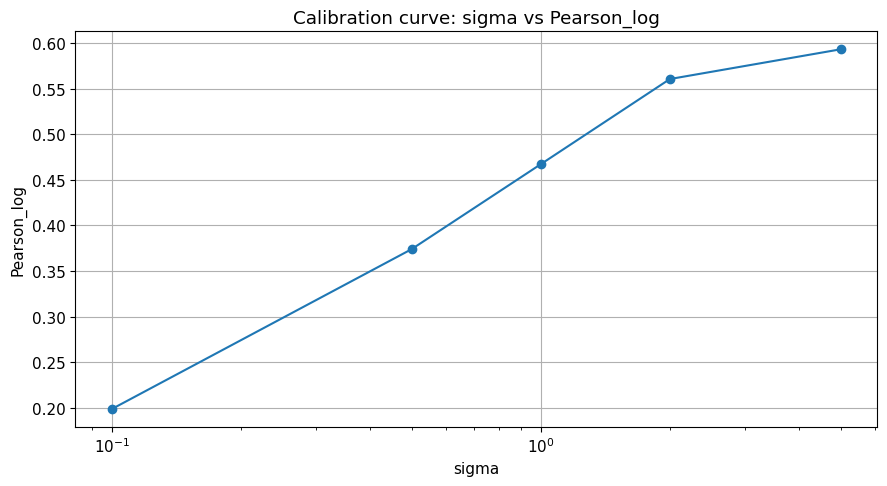

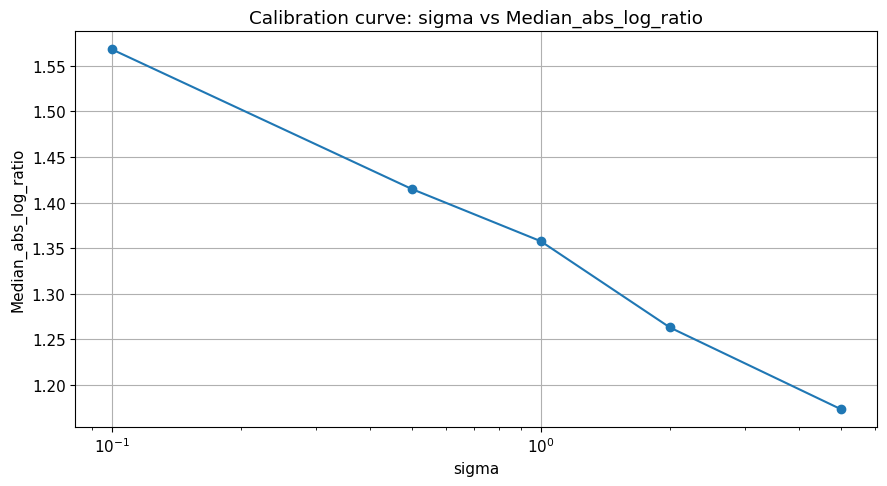

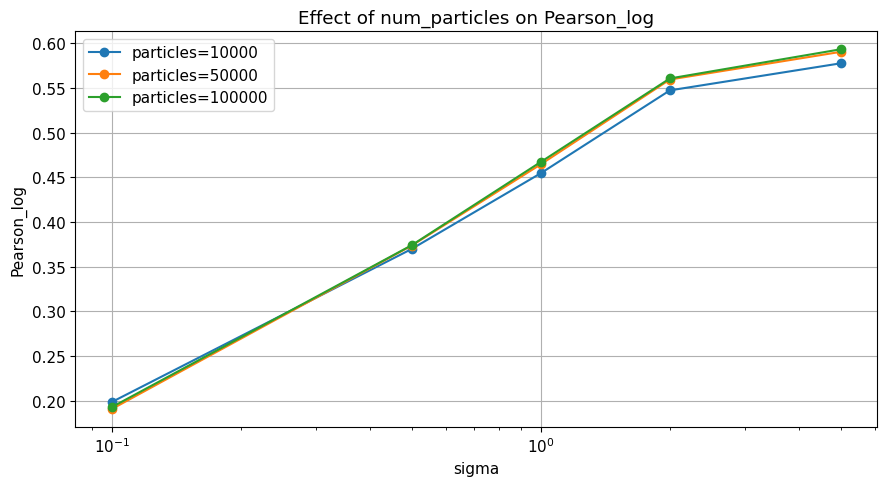

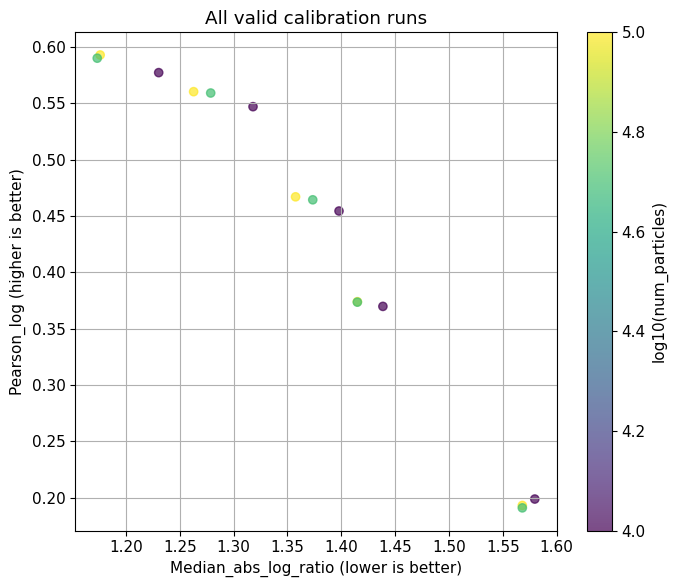

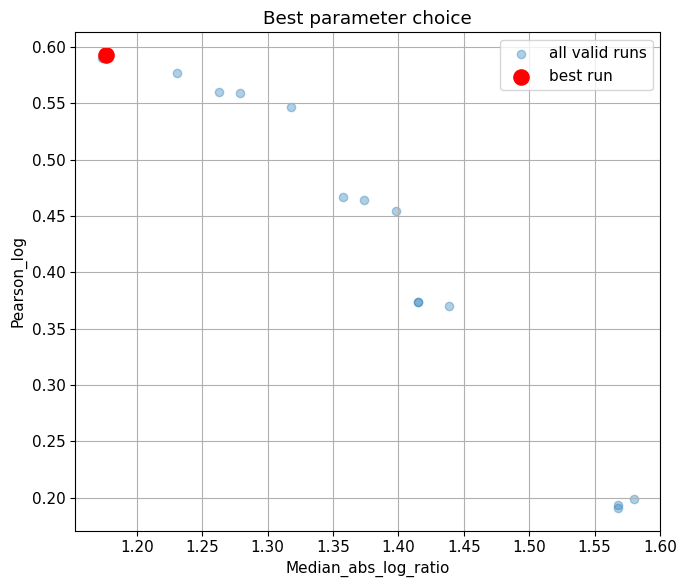

In [35]:
# Plots for relational-FERM calibration results
# Assumes you already have a calibration dataframe called calib_df.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "calib_df_valid" not in globals():
    calib_df_valid = calib_df.copy()

plot_df = calib_df_valid.copy()
plot_df = plot_df[plot_df["pred_unique"] > 1].copy()

metric_main = "Pearson_log"
metric_secondary = "Median_abs_log_ratio"

plot_df_main = plot_df.dropna(subset=[metric_main]).copy()
plot_df_secondary = plot_df.dropna(subset=[metric_secondary]).copy()

print("Best runs by Pearson_log:")
display(
    plot_df_main.sort_values(
        ["Pearson_log", "Median_abs_log_ratio"],
        ascending=[False, True],
    ).head(10)
)

print("Best runs by Median_abs_log_ratio:")
display(
    plot_df_secondary.sort_values(
        ["Median_abs_log_ratio", "Pearson_log"],
        ascending=[True, False],
    ).head(10)
)

best_row = plot_df_main.sort_values(
    ["Pearson_log", "Median_abs_log_ratio"],
    ascending=[False, True],
).iloc[0]

print("\nChosen best parameters:")
display(best_row.to_frame().T)

# --------------------------------------------------
# 1. sigma vs Pearson_log
# --------------------------------------------------
curve = (
    plot_df_main.groupby("sigma", as_index=False)[metric_main]
    .max()
    .sort_values("sigma")
)

plt.figure(figsize=(9, 5))
plt.plot(curve["sigma"], curve[metric_main], marker="o")
plt.xscale("log")
plt.xlabel("sigma")
plt.ylabel(metric_main)
plt.title("Calibration curve: sigma vs Pearson_log")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. sigma vs Median_abs_log_ratio
# --------------------------------------------------
curve_err = (
    plot_df_secondary.groupby("sigma", as_index=False)[metric_secondary]
    .min()
    .sort_values("sigma")
)

plt.figure(figsize=(9, 5))
plt.plot(curve_err["sigma"], curve_err[metric_secondary], marker="o")
plt.xscale("log")
plt.xlabel("sigma")
plt.ylabel(metric_secondary)
plt.title("Calibration curve: sigma vs Median_abs_log_ratio")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. effect of num_particles
# --------------------------------------------------
plt.figure(figsize=(9, 5))
for num_particles in sorted(plot_df_main["num_particles"].dropna().unique()):
    tmp = plot_df_main[plot_df_main["num_particles"] == num_particles].copy()
    tmp = tmp.groupby("sigma", as_index=False)[metric_main].max().sort_values("sigma")
    plt.plot(tmp["sigma"], tmp[metric_main], marker="o", label=f"particles={int(num_particles)}")

plt.xscale("log")
plt.xlabel("sigma")
plt.ylabel(metric_main)
plt.title("Effect of num_particles on Pearson_log")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. scatter of all valid runs
# --------------------------------------------------
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    plot_df["Median_abs_log_ratio"],
    plot_df["Pearson_log"],
    c=np.log10(plot_df["num_particles"]),
    alpha=0.7,
)
plt.colorbar(sc, label="log10(num_particles)")
plt.xlabel("Median_abs_log_ratio (lower is better)")
plt.ylabel("Pearson_log (higher is better)")
plt.title("All valid calibration runs")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(
    plot_df["Median_abs_log_ratio"],
    plot_df["Pearson_log"],
    alpha=0.35,
    label="all valid runs",
)
plt.scatter(
    [best_row["Median_abs_log_ratio"]],
    [best_row["Pearson_log"]],
    color="red",
    s=120,
    label="best run",
)
plt.xlabel("Median_abs_log_ratio")
plt.ylabel("Pearson_log")
plt.title("Best parameter choice")
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

from pathlib import Path

import numpy as np
import pandas as pd

from src.ferm.config import Config
import importlib
import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.plotting import plot_rm_vs_ferm_error_scatter, plot_timeseries_migrants
from src.ferm.preprocessing import filter_flows_by_continent, split_flows_by_period
from src.ferm.utils import (
    add_niche,
    build_master_country_table,
    load_country_geometries_global,
    load_migration_data,
    load_niche_data,
    load_population_data,
    prepare_nodes,
)


RELATIONAL_FEATURES = {
    "scaled_sci_2021": "positive",
    "comrelig": "positive",
    "tradeflow_baci": "positive",
    "manuf_tradeflow_baci": "positive",
    "dist": "negative",
    "distcap": "negative",
    "distw_harmonic": "negative",
    "distw_arithmetic": "negative",
    "diplo_disagreement": "negative",
}


def rescale_relational_feature(
    values: pd.Series,
    direction: str = "positive",
) -> pd.Series:
    """
    Rescale one bilateral feature to [-1, 1] so different Sigma candidates
    are numerically comparable across runs and 0 keeps a neutral meaning.
    """
    x = pd.to_numeric(values, errors="coerce")
    out = pd.Series(np.nan, index=x.index, dtype=float)

    valid = x.notna()
    if valid.sum() == 0:
        return out

    x_valid = x[valid]
    x_min = x_valid.min()
    x_max = x_valid.max()

    if pd.isna(x_min) or pd.isna(x_max) or x_min == x_max:
        out.loc[valid] = 0.0
        return out

    scaled = 2.0 * (x - x_min) / (x_max - x_min) - 1.0

    if direction == "positive":
        out.loc[valid] = scaled.loc[valid]
    elif direction == "negative":
        out.loc[valid] = -scaled.loc[valid]
    else:
        raise ValueError("`direction` must be 'positive' or 'negative'.")

    return out


def build_relational_feature_table(
    nodes: pd.DataFrame,
    gravity_pairs: pd.DataFrame,
    feature_col: str,
    direction: str,
) -> pd.DataFrame:
    """
    Map CEPII iso3 corridors onto model node codes and create Sigma_ij.
    """
    if "iso3" not in nodes.columns:
        raise ValueError("`nodes` must contain an `iso3` column.")

    code_lookup = nodes[["code", "iso3"]].dropna().drop_duplicates().copy()
    code_lookup["iso3"] = code_lookup["iso3"].astype(str).str.strip().str.upper()

    scoped = gravity_pairs[["iso3_o", "iso3_d", feature_col]].copy()
    scoped["iso3_o"] = scoped["iso3_o"].astype(str).str.strip().str.upper()
    scoped["iso3_d"] = scoped["iso3_d"].astype(str).str.strip().str.upper()

    mapped = scoped.merge(
        code_lookup.rename(columns={"code": "country_from", "iso3": "origin_iso3"}),
        left_on="iso3_o",
        right_on="origin_iso3",
        how="inner",
    )
    mapped = mapped.merge(
        code_lookup.rename(columns={"code": "country_to", "iso3": "destination_iso3"}),
        left_on="iso3_d",
        right_on="destination_iso3",
        how="inner",
    )

    mapped = mapped[mapped["origin_iso3"] != mapped["destination_iso3"]].copy()
    mapped["Sigma_ij"] = rescale_relational_feature(mapped[feature_col], direction)
    mapped = mapped.dropna(subset=["Sigma_ij"]).copy()

    return mapped[
        ["country_from", "country_to", "origin_iso3", "destination_iso3", feature_col, "Sigma_ij"]
    ].drop_duplicates(["origin_iso3", "destination_iso3"])


def build_destination_sigma(nodes: pd.DataFrame, niche_col: str = "niche") -> pd.DataFrame:
    """
    Traditional FERM Sigma: Sigma[i, i] = mu_i and Sigma[i, j] = mu_j.
    """
    node_values = nodes.set_index("iso3")[niche_col].astype(float).fillna(0.0)
    codes = node_values.index.astype(str).str.strip().str.upper().tolist()
    values = node_values.to_numpy()
    return pd.DataFrame(
        np.tile(values, (len(values), 1)),
        index=codes,
        columns=codes,
    )


def build_relational_sigma(
    nodes: pd.DataFrame,
    corridor_features: pd.DataFrame,
    value_col: str = "Sigma_ij",
    fill_value: float = 0.0,
) -> pd.DataFrame:
    """
    Relational FERM Sigma: neutral diagonal and corridor-specific off-diagonal entries.
    """
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    values = np.full((len(codes), len(codes)), float(fill_value), dtype=float)
    np.fill_diagonal(values, 0.0)
    Sigma = pd.DataFrame(values, index=codes, columns=codes)

    for row in corridor_features.itertuples(index=False):
        origin = getattr(row, "origin_iso3")
        destination = getattr(row, "destination_iso3")
        if origin in Sigma.index and destination in Sigma.columns and origin != destination:
            Sigma.loc[origin, destination] = float(getattr(row, value_col))

    return Sigma


def build_abel_sigma(
    nodes: pd.DataFrame,
    abel_path: str | Path = "abel-database-s2.xlsx",
    sheet_name: str = "2005-10",
    normalize_by: str = "destination",
    transform: str = "column_log_zscore_clipped",
    fill_value: float = 0.0,
) -> pd.DataFrame:
    """
    Build a Sigma matrix from Abel bilateral migration stocks.

    Abel rows are origins and columns are destinations. The default normalization
    divides each stock from origin i to destination j by destination population,
    making Sigma[i, j] a destination-population-normalized migrant-stock intensity.
    The off-diagonal values are then log-compressed, column-wise z-scored, and clipped so
    each destination has its own neutral baseline and negative values are possible.
    """
    raw = pd.read_excel(abel_path, sheet_name=sheet_name, header=None)

    destination_codes = raw.iloc[2, 3:-1].astype(str).str.strip().str.upper().tolist()
    matrix = raw.iloc[3:, 3:-1].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    origin_codes = raw.iloc[3:, 2].astype(str).str.strip().str.upper().tolist()
    abel = pd.DataFrame(matrix.to_numpy(dtype=float), index=origin_codes, columns=destination_codes)
    abel = abel.groupby(level=0).sum()
    abel = abel.T.groupby(level=0).sum().T

    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    stocks = abel.reindex(index=codes, columns=codes).fillna(float(fill_value))

    populations = nodes.set_index("iso3")["population"].astype(float)
    populations.index = populations.index.astype(str).str.strip().str.upper()
    populations = populations.reindex(codes).replace(0.0, np.nan)

    if normalize_by == "destination":
        normalized = stocks.div(populations, axis="columns")
    elif normalize_by == "origin":
        normalized = stocks.div(populations, axis="index")
    else:
        raise ValueError("normalize_by must be 'destination' or 'origin'.")

    normalized = normalized.replace([np.inf, -np.inf], np.nan).fillna(float(fill_value))
    values = normalized.to_numpy(dtype=float, copy=True)
    off_diag = ~np.eye(len(codes), dtype=bool)

    if transform == "log_zscore":
        values = np.log1p(values)
        reference = values[off_diag]
        center = np.nanmean(reference)
        scale = np.nanstd(reference)
        values = (values - center) / scale if scale > 0 else values - center
    elif transform == "row_log_zscore":
        values = np.log1p(values)
        for row_idx in range(len(codes)):
            row_mask = np.ones(len(codes), dtype=bool)
            row_mask[row_idx] = False
            reference = values[row_idx, row_mask]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[row_idx, :] = (values[row_idx, :] - center) / scale
            else:
                values[row_idx, :] = values[row_idx, :] - center
    elif transform == "column_log_zscore":
        values = np.log1p(values)
        for col_idx in range(len(codes)):
            col_mask = np.ones(len(codes), dtype=bool)
            col_mask[col_idx] = False
            reference = values[col_mask, col_idx]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[:, col_idx] = (values[:, col_idx] - center) / scale
            else:
                values[:, col_idx] = values[:, col_idx] - center
    elif transform == "column_log_zscore_clipped":
        values = np.log1p(values)
        for col_idx in range(len(codes)):
            col_mask = np.ones(len(codes), dtype=bool)
            col_mask[col_idx] = False
            reference = values[col_mask, col_idx]
            center = np.nanmean(reference)
            scale = np.nanstd(reference)
            if scale > 0:
                values[:, col_idx] = (values[:, col_idx] - center) / scale
            else:
                values[:, col_idx] = values[:, col_idx] - center
        values = np.clip(values, -1.0, 1.0)
    elif transform == "zscore":
        reference = values[off_diag]
        center = np.nanmean(reference)
        scale = np.nanstd(reference)
        values = (values - center) / scale if scale > 0 else values - center
    elif transform == "minmax_centered":
        reference = values[off_diag]
        min_value = np.nanmin(reference)
        max_value = np.nanmax(reference)
        if max_value > min_value:
            values = 2.0 * (values - min_value) / (max_value - min_value) - 1.0
        else:
            values = np.zeros_like(values)
    else:
        raise ValueError("transform must be 'log_zscore', 'row_log_zscore', 'column_log_zscore', 'column_log_zscore_clipped', 'zscore', or 'minmax_centered'.")

    values = np.nan_to_num(values, nan=float(fill_value), posinf=float(fill_value), neginf=float(fill_value))
    np.fill_diagonal(values, 0.0)
    return pd.DataFrame(values, index=codes, columns=codes)


def build_gravity_distance_matrix(
    nodes: pd.DataFrame,
    gravity_pairs: pd.DataFrame,
    distance_col: str = "dist",
) -> pd.DataFrame:
    """
    Build an ISO3-by-ISO3 distance matrix from CEPII Gravity distances.
    Rows are origins and columns are destinations.
    """
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    scoped = gravity_pairs[["iso3_o", "iso3_d", distance_col]].copy()
    scoped["iso3_o"] = scoped["iso3_o"].astype(str).str.strip().str.upper()
    scoped["iso3_d"] = scoped["iso3_d"].astype(str).str.strip().str.upper()
    scoped[distance_col] = pd.to_numeric(scoped[distance_col], errors="coerce")

    pivot = scoped.pivot_table(
        index="iso3_o",
        columns="iso3_d",
        values=distance_col,
        aggfunc="mean",
    )
    distances = pivot.reindex(index=codes, columns=codes)
    distances = distances.combine_first(distances.T)

    values = distances.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(values, 0.0)
    distances = pd.DataFrame(values, index=codes, columns=codes)

    if distances.isna().any().any():
        missing = [
            (origin, destination)
            for origin in distances.index
            for destination in distances.columns
            if pd.isna(distances.loc[origin, destination])
        ]
        raise ValueError(
            f"CEPII `{distance_col}` is missing {len(missing)} node-pair distances; "
            f"first missing pairs: {missing[:10]}"
        )

    return distances


def summarize_comparison(comp: pd.DataFrame, label: str) -> dict[str, float | str]:
    comp = comp.copy()
    observed_col = "total_migrants" if "total_migrants" in comp.columns else "num_migrants"

    return {
        "model": label,
        "pairs": len(comp),
        "observed_total": comp[observed_col].sum(),
        "predicted_total": comp["predicted_migrants"].sum(),
        "MAE": np.mean(np.abs(comp["predicted_migrants"] - comp[observed_col])),
        "RMSE": np.sqrt(np.mean((comp["predicted_migrants"] - comp[observed_col]) ** 2)),
        "Pearson": comp[observed_col].corr(comp["predicted_migrants"], method="pearson"),
        "Spearman": comp[observed_col].corr(comp["predicted_migrants"], method="spearman"),
        "Pearson_log": np.log10(comp[observed_col] + 1).corr(
            np.log10(comp["predicted_migrants"] + 1),
            method="pearson",
        ),
        "Spearman_log": np.log10(comp[observed_col] + 1).corr(
            np.log10(comp["predicted_migrants"] + 1),
            method="spearman",
        ),
        "Median_abs_log_ratio": np.median(
            np.abs(np.log10((comp["predicted_migrants"] + 1) / (comp[observed_col] + 1)))
        ),
    }


Computing period: test_2019_h2
                          model  pairs  observed_total  predicted_total         MAE         RMSE  Pearson  Spearman  Pearson_log  Spearman_log  Median_abs_log_ratio
                           FERM   2070       6186048.0        6186048.0 4282.145621 17640.157951 0.247470  0.711535     0.700997      0.711535              0.847320
                FERM_abel_stock   2070       6186048.0        6186048.0 4412.492548 19595.122275 0.184161  0.656813     0.649515      0.656813              1.033233
       FERM_relational_comrelig   2070       6186048.0        6186048.0 4382.422272 18589.472186 0.173272  0.655422     0.652577      0.655422              0.979242
FERM_relational_scaled_sci_2021   2070       6186048.0        6186048.0 4287.302730 18166.468162 0.197959  0.660720     0.658791      0.660720              0.940683
                             RM   2070       6186048.0        6186048.0 4384.796104 18917.088907 0.182578  0.655662     0.645768      0.655662  

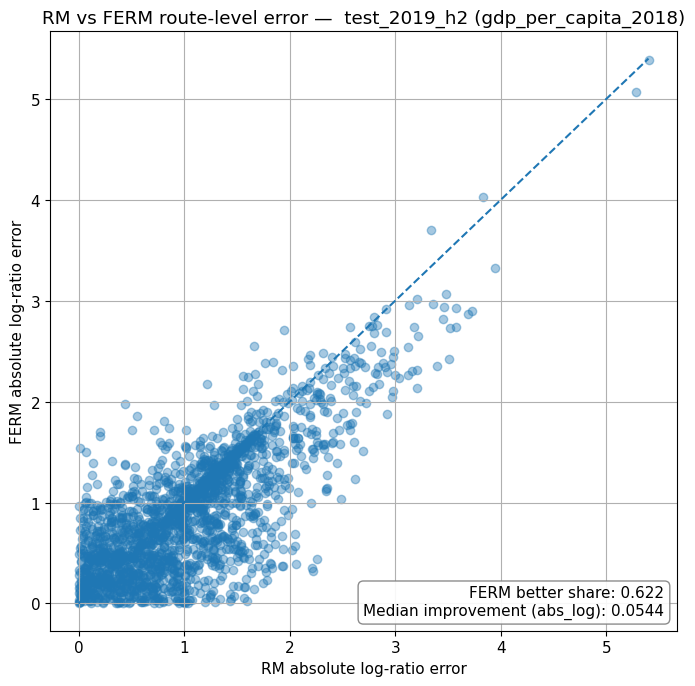

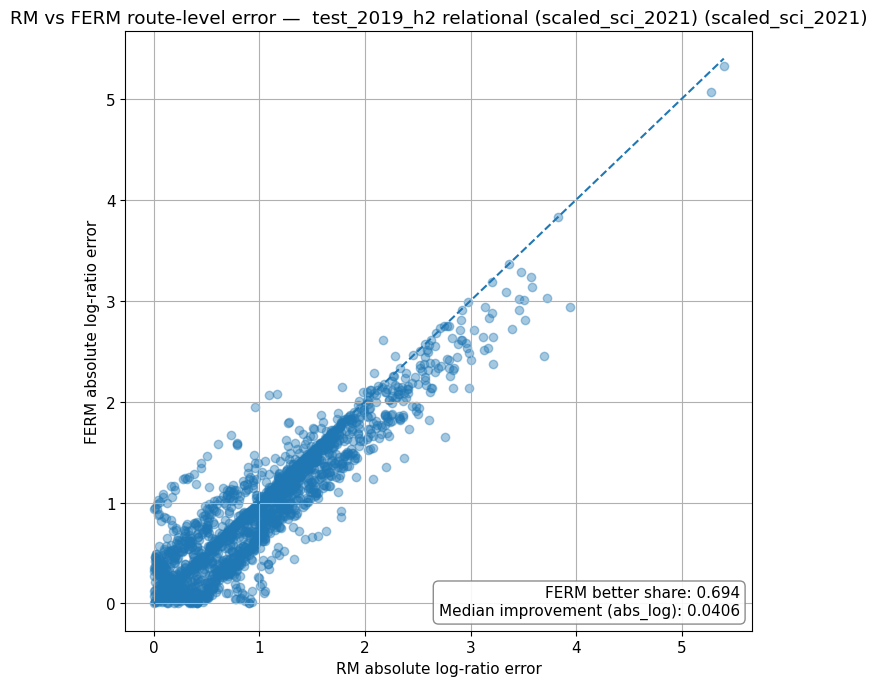

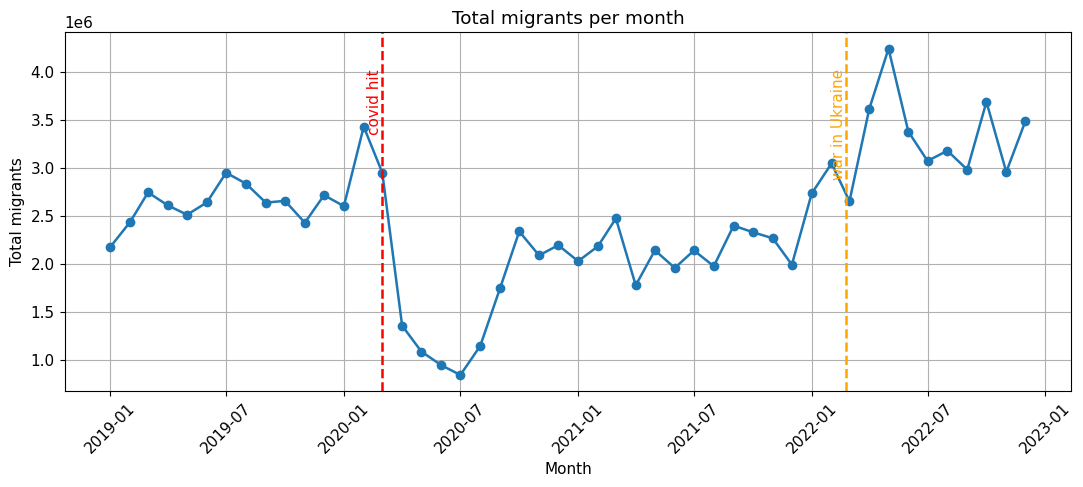

In [57]:
# %% Configuration

config = Config(
    niche_method="zscore_log",
    niche_type="gdp_per_capita_2018",
    target_continent="Asia",
    num_particles=5000000,
    sigma=5.0,
    verbose=True,
)

gravity_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")
relational_feature_year = 2019
distance_col = "dist"
abel_sheet_name = "2005-10"
relational_features_to_run = [
    "scaled_sci_2021",
    "comrelig",
    #"dist",
    #"diplo_disagreement",
]
only_label = "test_2019_h2"


# %% Data preparation

migrations = load_migration_data(config.flow_path)
populations = load_population_data(config.pop_path)

gravity_pairs = pd.read_csv(
    gravity_path,
    usecols=["year", "iso3_o", "iso3_d", distance_col] + relational_features_to_run,
)
gravity_pairs = gravity_pairs[gravity_pairs["year"] == relational_feature_year].copy()

world_gdf, country_geo = load_country_geometries_global()

if config.target_continent == "Americas":
    continent_gdf = world_gdf[
        world_gdf["CONTINENT"].isin(["North America", "South America", "Central America"])
    ].copy()
elif config.target_continent is None:
    continent_gdf = world_gdf.copy()
else:
    continent_gdf = world_gdf[world_gdf["CONTINENT"] == config.target_continent].copy()

niche_df = load_niche_data(config.gdp_path, niche_type=config.niche_type)

master_country = build_master_country_table(
    country_geo,
    populations,
    niche_df=niche_df,
    niche_col=config.niche_type,
)

flows, country = filter_flows_by_continent(
    master_country,
    migrations,
    niche_type=config.niche_type,
    continent=config.target_continent,
)

pair_lookup = split_flows_by_period(flows, master_country)

country = add_niche(
    country,
    niche_col=config.niche_type,
    method=config.niche_method,
)


# %% Main comparison loop

comparisons_rm: dict[str, dict[str, object]] = {}
comparisons_ferm: dict[str, dict[str, object]] = {}
comparisons_relational: dict[str, dict[str, dict[str, object]]] = {}
comparisons_abel: dict[str, dict[str, object]] = {}
summary_rows: list[dict[str, float | str]] = []

for label, flows_partial in pair_lookup.items():
    flows_partial = flows_partial.rename({"total_migrants": "num_migrants"}, axis=1)

    if only_label is not None and label != only_label:
        continue
    if len(flows_partial) == 0:
        continue

    print(f"Computing period: {label}")

    nodes_period = prepare_nodes(country, flows_partial)
    distance_matrix = build_gravity_distance_matrix(
        nodes_period,
        gravity_pairs,
        distance_col=distance_col,
    )

    rm = RM(nodes=nodes_period, flows=flows_partial, distance_matrix=distance_matrix)
    rm_results = rm.run()
    comparisons_rm[label] = {
        "nodes": nodes_period,
        "D": rm_results.distance_matrix,
        "S": rm_results.intervening_population_matrix,
        "P": rm_results.probability_matrix,
        "comparison": rm_results.comparison,
    }
    summary_rows.append(summarize_comparison(rm_results.comparison, label="RM"))

    destination_sigma = build_destination_sigma(nodes_period, niche_col="niche")
    ferm = FERM(
        nodes=nodes_period,
        flows=flows_partial,
        features=destination_sigma,
        distance_matrix=distance_matrix,
    )
    ferm_results = ferm.run(
        num_particles=config.num_particles,
        sigma=config.sigma,
        niche_col="niche",
        verbose=False,
    )
    comparisons_ferm[label] = {
        "nodes": nodes_period,
        "D": ferm_results.distance_matrix,
        "P": ferm_results.probability_matrix,
        "comparison": ferm_results.comparison,
    }
    summary_rows.append(summarize_comparison(ferm_results.comparison, label="FERM"))


    abel_sigma = build_abel_sigma(
        nodes=nodes_period,
        abel_path="abel-database-s2.xlsx",
        sheet_name=abel_sheet_name,
        normalize_by="destination",
        transform="column_log_zscore_clipped",
    )
    abel_model = FERM(
        nodes=nodes_period,
        flows=flows_partial,
        features=abel_sigma,
        distance_matrix=distance_matrix,
    )
    abel_results = abel_model.run(
        num_particles=config.num_particles,
        sigma=config.sigma,
        verbose=False,
    )
    comparisons_abel[label] = {
        "nodes": nodes_period,
        "D": abel_results.distance_matrix,
        "Sigma": abel_sigma,
        "P": abel_results.probability_matrix,
        "comparison": abel_results.comparison,
    }
    summary_rows.append(
        summarize_comparison(
            abel_results.comparison,
            label="FERM_abel_stock",
        )
    )

    comparisons_relational[label] = {}

    for feature_name in relational_features_to_run:
        direction = RELATIONAL_FEATURES[feature_name]
        relational_pairs = build_relational_feature_table(
            nodes=nodes_period,
            gravity_pairs=gravity_pairs,
            feature_col=feature_name,
            direction=direction,
        )

        sigma_matrix = build_relational_sigma(
            nodes=nodes_period,
            corridor_features=relational_pairs,
            value_col="Sigma_ij",
            fill_value=0.0,
        )

        relational_model = FERM(
            nodes=nodes_period,
            flows=flows_partial,
            features=sigma_matrix,
            distance_matrix=distance_matrix,
        )
        relational_results = relational_model.run(
            num_particles=config.num_particles,
            sigma=config.sigma,
            verbose=False,
        )

        comparisons_relational[label][feature_name] = {
            "nodes": nodes_period,
            "D": relational_results.distance_matrix,
            "Sigma": sigma_matrix,
            "corridor_features": relational_pairs,
            "P": relational_results.probability_matrix,
            "comparison": relational_results.comparison,
        }
        summary_rows.append(
            summarize_comparison(
                relational_results.comparison,
                label=f"FERM_relational_{feature_name}",
            )
        )


# %% Summaries

summary_df = pd.DataFrame(summary_rows)
if len(summary_df) > 0:
    print(summary_df.sort_values("model").to_string(index=False))


# %% Plot one baseline comparison plus one relational feature

plot_feature = "scaled_sci_2021"

comp_rm = comparisons_rm[only_label]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)
comp_ferm = comparisons_ferm[only_label]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)
comp_rel = comparisons_relational[only_label][plot_feature]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_ferm,
    label=only_label,
    metric="abs_log",
    niche_type=config.niche_type,
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_rel,
    label=f"{only_label} relational ({plot_feature})",
    metric="abs_log",
    niche_type=plot_feature,
)


# %% Time series

plot_timeseries_migrants(migrations)


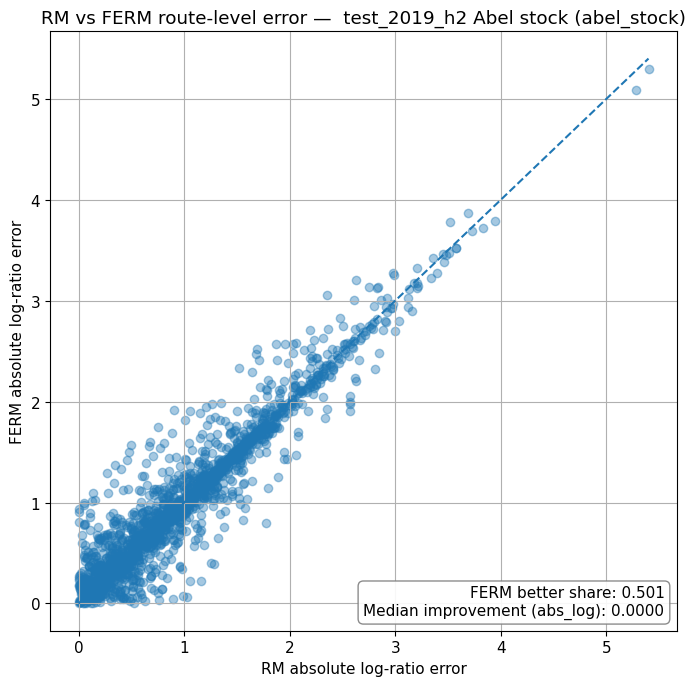

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,residual_rm,abs_error_rm,log_ratio_rm,abs_log_ratio_rm,predicted_ferm,residual_ferm,abs_error_ferm,log_ratio_ferm,abs_log_ratio_ferm,improvement_abs_error,improvement_abs_log
0,AFG,ARE,Afghanistan,United Arab Emirates,5743.0,5.044662,-5737.955338,5737.955338,-2.977842,2.977842,5.240566,-5737.759434,5737.759434,-2.963990,2.963990,0.195903,0.013852
1,AFG,ARM,Afghanistan,Armenia,5.0,1.461523,-3.538477,3.538477,-0.386947,0.386947,1.791503,-3.208497,3.208497,-0.332313,0.332313,0.329981,0.054634
2,AFG,AZE,Afghanistan,Azerbaijan,101.0,5.067951,-95.932049,95.932049,-1.225558,1.225558,5.927029,-95.072971,95.072971,-1.168053,1.168053,0.859078,0.057505
3,AFG,BGD,Afghanistan,Bangladesh,55.0,71.826662,16.826662,16.826662,0.114102,0.114102,84.024851,29.024851,29.024851,0.181358,0.181358,-12.198190,-0.067255
4,AFG,BHR,Afghanistan,Bahrain,22.0,0.743880,-21.256120,21.256120,-1.120211,1.120211,0.594377,-21.405623,21.405623,-1.159137,1.159137,-0.149502,-0.038925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,YEM,TLS,Yemen,East Timor,2.0,0.208860,-1.791140,1.791140,-0.394745,0.394745,0.337002,-1.662998,1.662998,-0.350989,0.350989,0.128142,0.043756
2066,YEM,TUR,Yemen,Turkey,693.0,513.912842,-179.087158,179.087158,-0.129626,0.129626,303.356497,-389.643503,389.643503,-0.357977,0.357977,-210.556345,-0.228351
2067,YEM,TWN,Yemen,Taiwan,13.0,4.141623,-8.858377,8.858377,-0.435028,0.435028,7.014340,-5.985660,5.985660,-0.242260,0.242260,2.872717,0.192768
2068,YEM,UZB,Yemen,Uzbekistan,34.0,12.133632,-21.866368,21.866368,-0.425683,0.425683,12.132065,-21.867935,21.867935,-0.425735,0.425735,-0.001567,-0.000052


In [59]:
comp_abel = comparisons_abel[only_label]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_abel,
    label=f"{only_label} Abel stock",
    metric="abs_log",
    niche_type="abel_stock",
)


Running Abel FERM with sigma=0.1


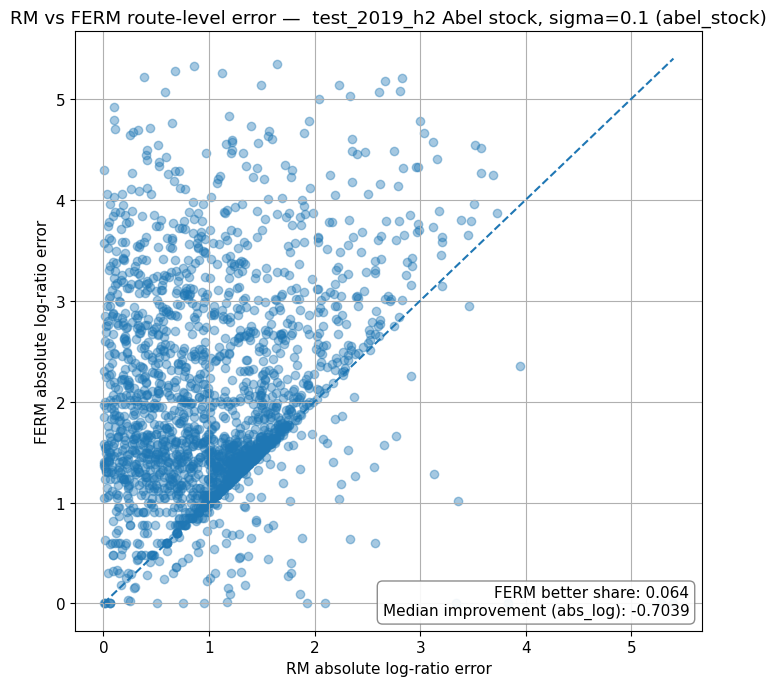

Running Abel FERM with sigma=0.25


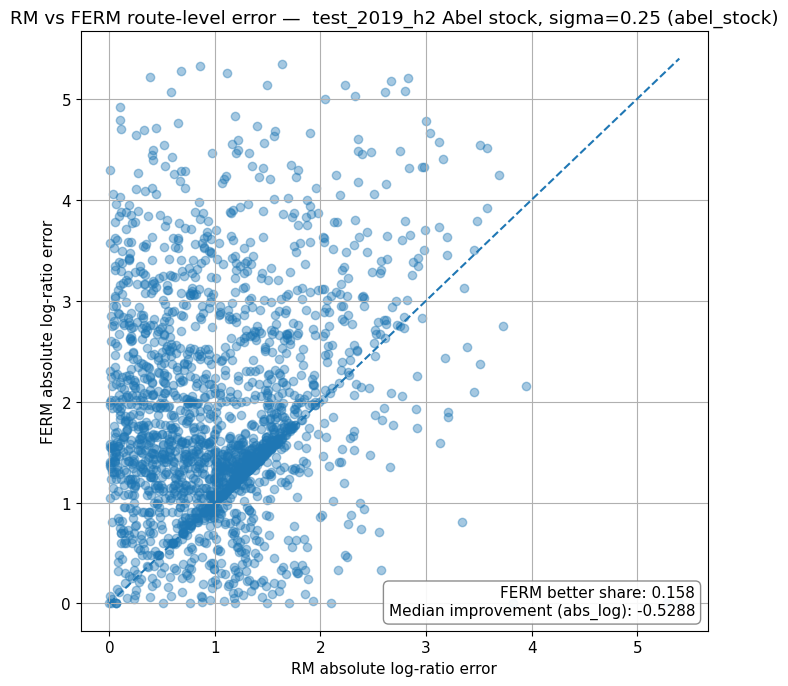

Running Abel FERM with sigma=0.5


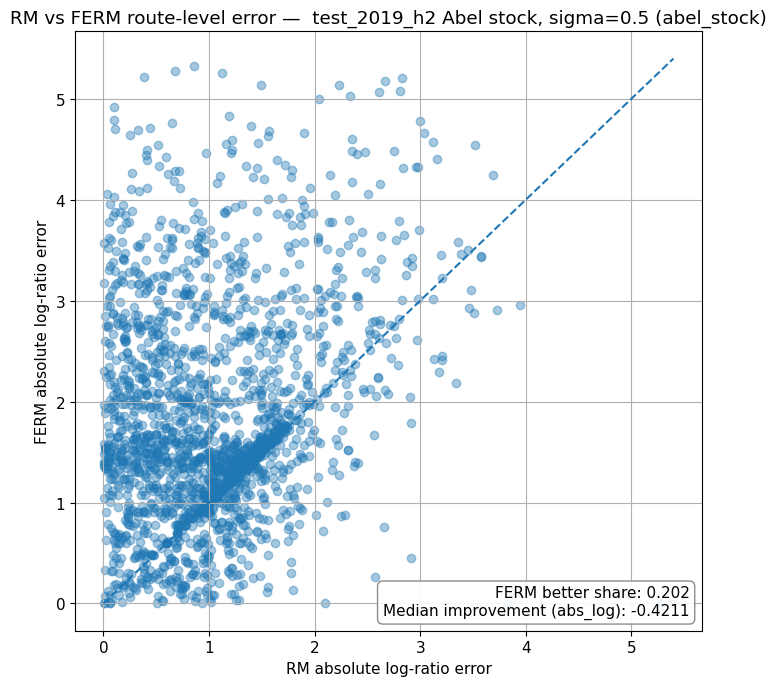

Running Abel FERM with sigma=1.0


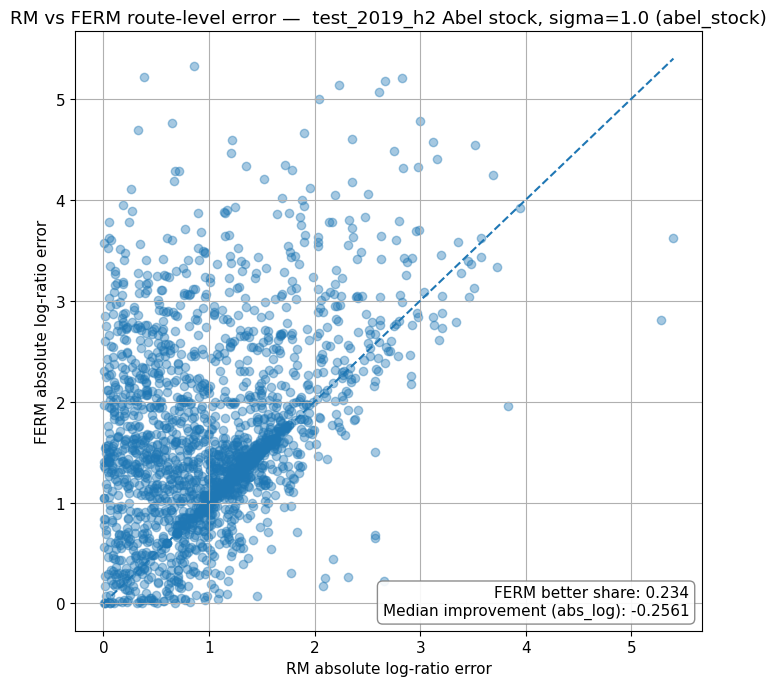

Running Abel FERM with sigma=2.0


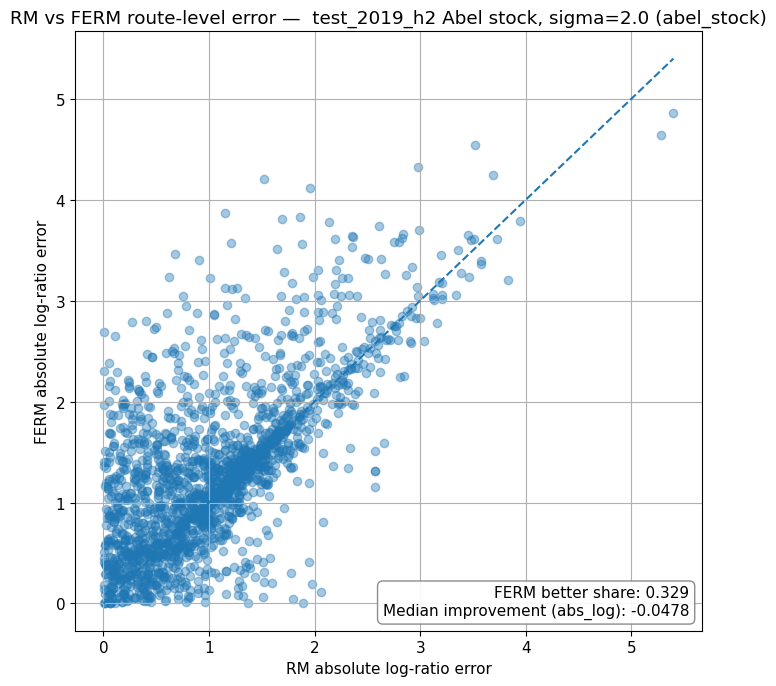

Running Abel FERM with sigma=5.0


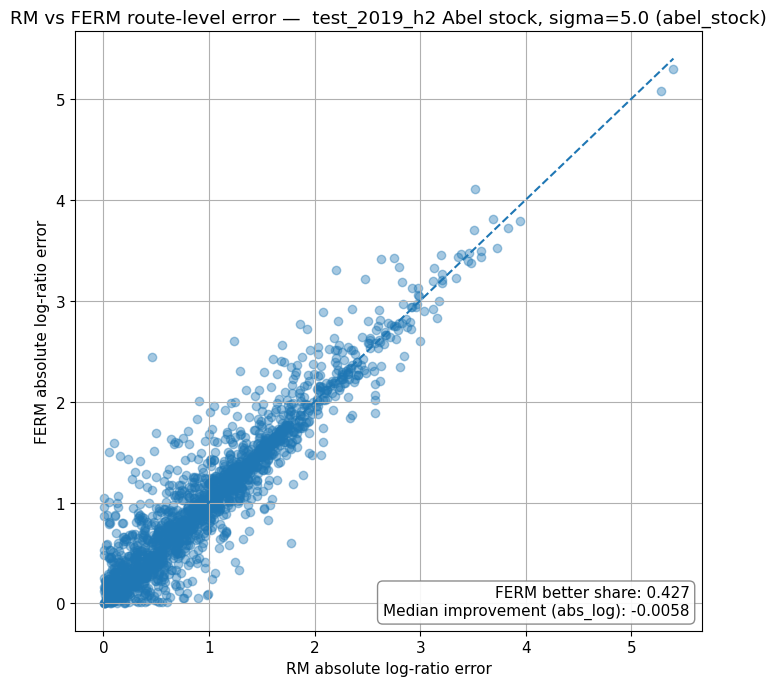

Running Abel FERM with sigma=7.0


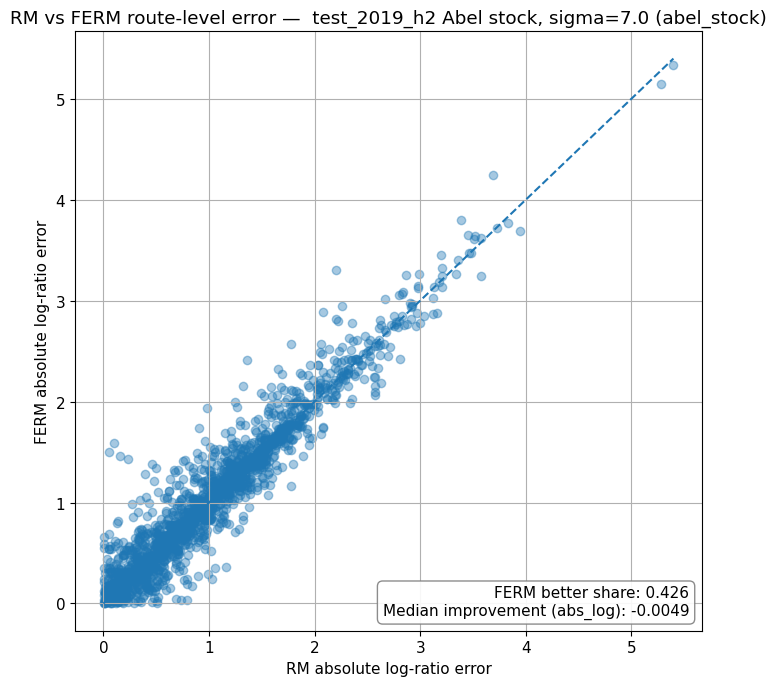

Running Abel FERM with sigma=9.0


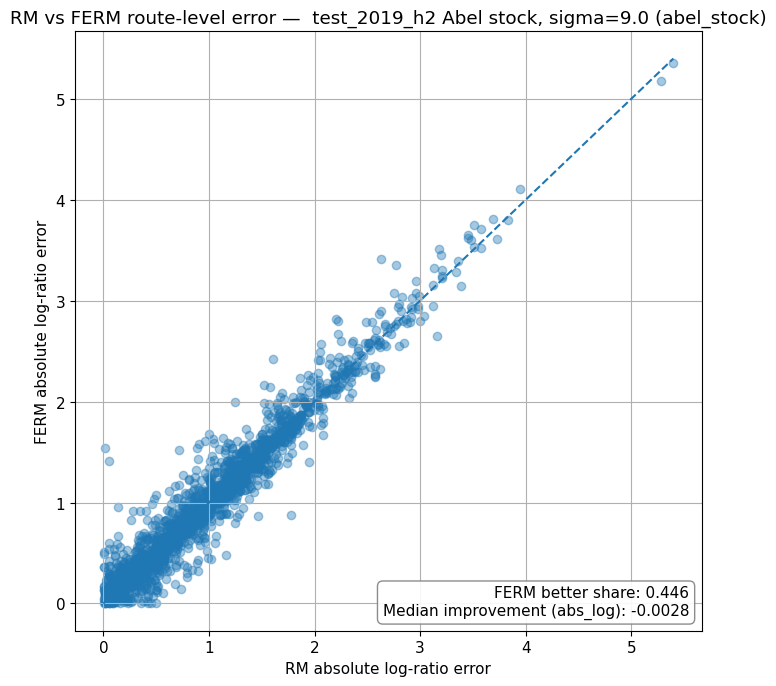

Running Abel FERM with sigma=10.0


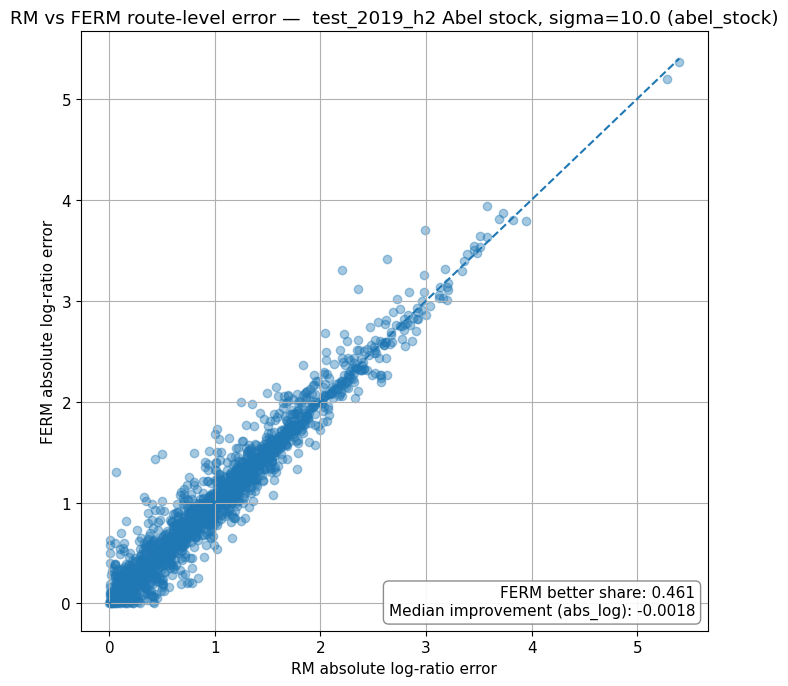

,sigma,num_particles,median_improvement_abs_log,share_better_abs_log,mean_improvement_abs_log
8,10.00,100000,-0.001768,0.460870,-0.014325
7,9.00,100000,-0.002829,0.446377,-0.016571
6,7.00,100000,-0.004918,0.425604,-0.026811
5,5.00,100000,-0.005770,0.427053,-0.041386
4,2.00,100000,-0.047790,0.329469,-0.240086
3,1.00,100000,-0.256146,0.233816,-0.590821
2,0.50,100000,-0.421074,0.201932,-0.744805
1,0.25,100000,-0.528841,0.157971,-0.797340
0,0.10,100000,-0.703916,0.064251,-0.953498


In [60]:
# Try different model sigma values for the Abel Sigma matrix and compare scatter plots

import importlib
import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.plotting import plot_rm_vs_ferm_error_scatter

required_names = [
    "pair_lookup",
    "country",
    "prepare_nodes",
    "build_abel_sigma",
    "build_gravity_distance_matrix",
    "plot_rm_vs_ferm_error_scatter",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(
        "Run the setup/main workflow cell first. Missing names: " + ", ".join(missing)
    )

abel_sigma_grid = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 7.0, 9.0, 10.0]
abel_num_particles = 100000  # increase after choosing a promising sigma
abel_label = only_label if "only_label" in globals() else "test_2019_h2"
abel_sheet = abel_sheet_name if "abel_sheet_name" in globals() else "2005-10"
abel_distance_col = distance_col if "distance_col" in globals() else "dist"

if "gravity_pairs" not in globals():
    gravity_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")
    gravity_pairs = pd.read_csv(
        gravity_path,
        usecols=["year", "iso3_o", "iso3_d", abel_distance_col],
    )
    gravity_pairs = gravity_pairs[gravity_pairs["year"] == 2019].copy()

flows_abel = pair_lookup[abel_label].rename({"total_migrants": "num_migrants"}, axis=1).copy()
nodes_abel = prepare_nodes(country, flows_abel)
D_abel = build_gravity_distance_matrix(nodes_abel, gravity_pairs, distance_col=abel_distance_col)
Sigma_abel = build_abel_sigma(
    nodes=nodes_abel,
    abel_path="abel-database-s2.xlsx",
    sheet_name=abel_sheet,
    normalize_by="destination",
    transform="column_log_zscore_clipped",
)

rm_abel = RM(nodes=nodes_abel, flows=flows_abel, distance_matrix=D_abel)
rm_abel_results = rm_abel.run()
comp_rm_abel = rm_abel_results.comparison.rename({"num_migrants": "total_migrants"}, axis=1)

abel_sigma_results = {}
abel_sigma_summary = []

for sigma_value in abel_sigma_grid:
    print(f"Running Abel FERM with sigma={sigma_value}")
    model = FERM(
        nodes=nodes_abel,
        flows=flows_abel,
        features=Sigma_abel,
        distance_matrix=D_abel,
    )
    result = model.run(
        num_particles=abel_num_particles,
        sigma=sigma_value,
        verbose=False,
    )

    comp_abel_sigma = result.comparison.rename({"num_migrants": "total_migrants"}, axis=1)
    route_df = plot_rm_vs_ferm_error_scatter(
        comp_rm_abel,
        comp_abel_sigma,
        label=f"{abel_label} Abel stock, sigma={sigma_value}",
        metric="abs_log",
        niche_type="abel_stock",
    )

    abel_sigma_results[sigma_value] = {
        "result": result,
        "comparison": comp_abel_sigma,
        "route_comparison": route_df,
    }
    abel_sigma_summary.append({
        "sigma": sigma_value,
        "num_particles": abel_num_particles,
        "median_improvement_abs_log": route_df["improvement_abs_log"].median(),
        "share_better_abs_log": (route_df["improvement_abs_log"] > 0).mean(),
        "mean_improvement_abs_log": route_df["improvement_abs_log"].mean(),
    })

abel_sigma_summary = pd.DataFrame(abel_sigma_summary).sort_values(
    ["median_improvement_abs_log", "share_better_abs_log"],
    ascending=[False, False],
)
display(abel_sigma_summary)


Pearson correlations among log predictions and observed flows:


,log_pred_rm,log_pred_gdp_ferm,log_pred_abel_ferm,log_num_migrants
log_pred_rm,1.000000,0.921732,0.983494,0.645768
log_pred_gdp_ferm,0.921732,1.000000,0.911452,0.700997
log_pred_abel_ferm,0.983494,0.911452,1.000000,0.649515
log_num_migrants,0.645768,0.700997,0.649515,1.000000


,variant,corr_with_RM_log_pred,corr_with_observed_log,median_abs_log_move_from_RM,mean_abs_log_move_from_RM
0,GDP-FERM,0.921732,0.700997,0.279283,0.396535
1,Abel-FERM,0.983494,0.649515,0.067856,0.148593


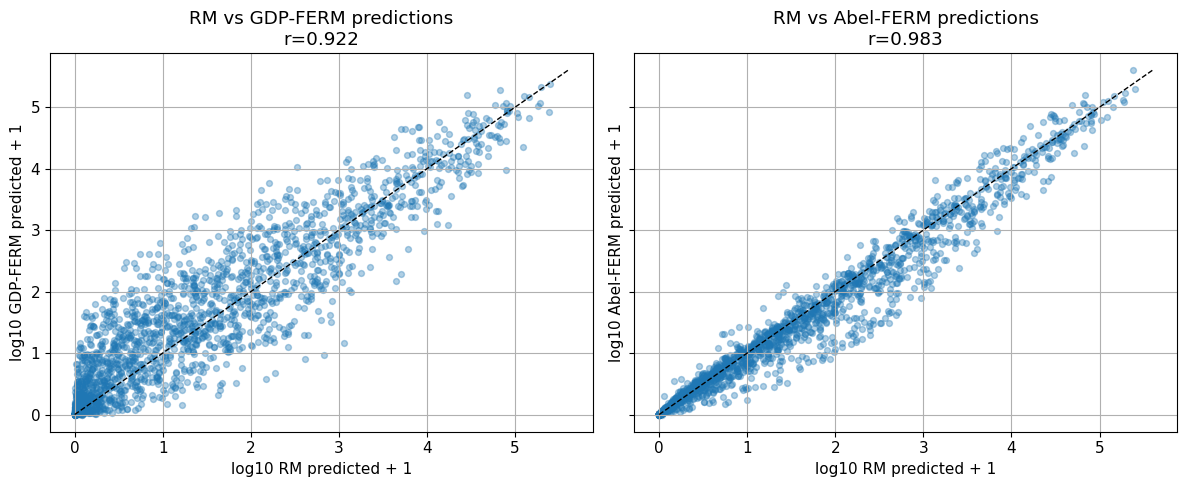

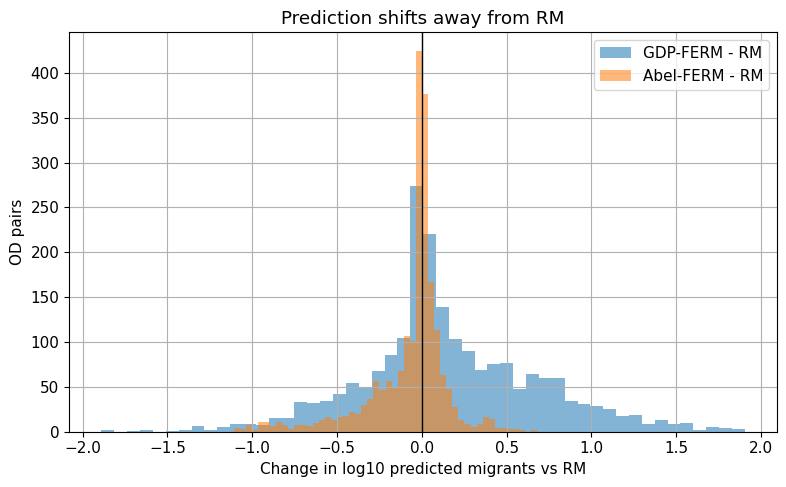

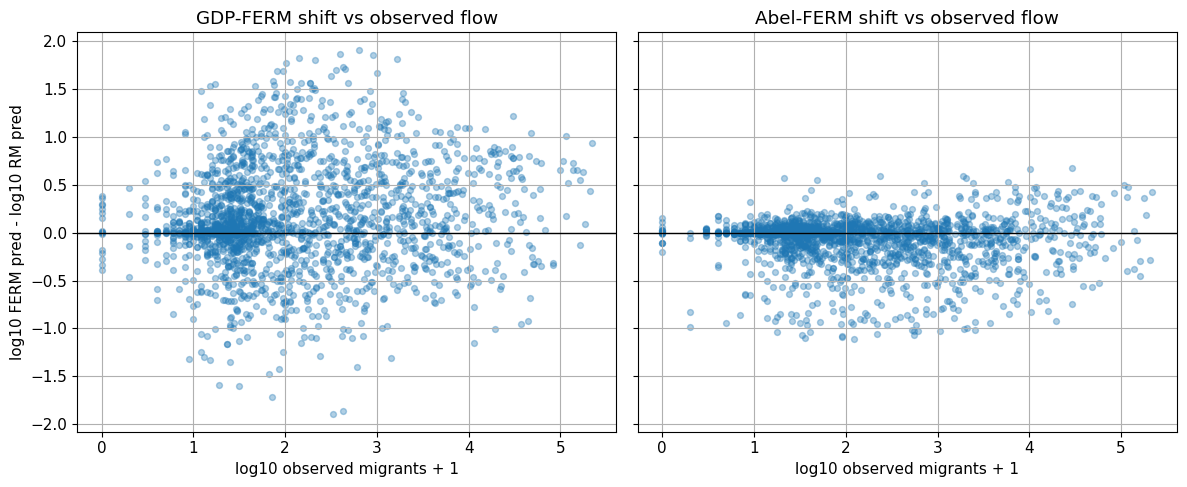

In [61]:
# Diagnostics: how similar are RM, GDP-FERM, and Abel-FERM predictions?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_names = ["comparisons_rm", "comparisons_ferm", "comparisons_abel", "only_label"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError("Run the main workflow cell first. Missing names: " + ", ".join(missing))


def prediction_table_for_diagnostics(label):
    rm = comparisons_rm[label]["comparison"].copy()
    gdp = comparisons_ferm[label]["comparison"].copy()
    abel = comparisons_abel[label]["comparison"].copy()

    keep = ["country_from", "country_to", "num_migrants", "predicted_migrants"]
    rm = rm[keep].rename(columns={"predicted_migrants": "pred_rm"})
    gdp = gdp[["country_from", "country_to", "predicted_migrants"]].rename(
        columns={"predicted_migrants": "pred_gdp_ferm"}
    )
    abel = abel[["country_from", "country_to", "predicted_migrants"]].rename(
        columns={"predicted_migrants": "pred_abel_ferm"}
    )

    out = rm.merge(gdp, on=["country_from", "country_to"], how="inner")
    out = out.merge(abel, on=["country_from", "country_to"], how="inner")

    for col in ["num_migrants", "pred_rm", "pred_gdp_ferm", "pred_abel_ferm"]:
        out[f"log_{col}"] = np.log10(out[col] + 1.0)

    out["delta_log_gdp_vs_rm"] = out["log_pred_gdp_ferm"] - out["log_pred_rm"]
    out["delta_log_abel_vs_rm"] = out["log_pred_abel_ferm"] - out["log_pred_rm"]
    out["abs_delta_log_gdp_vs_rm"] = out["delta_log_gdp_vs_rm"].abs()
    out["abs_delta_log_abel_vs_rm"] = out["delta_log_abel_vs_rm"].abs()

    return out


diag_df = prediction_table_for_diagnostics(only_label)

corr_cols = ["log_pred_rm", "log_pred_gdp_ferm", "log_pred_abel_ferm", "log_num_migrants"]
corr_table = diag_df[corr_cols].corr(method="pearson")
print("Pearson correlations among log predictions and observed flows:")
display(corr_table)

summary = pd.DataFrame([
    {
        "variant": "GDP-FERM",
        "corr_with_RM_log_pred": diag_df["log_pred_rm"].corr(diag_df["log_pred_gdp_ferm"]),
        "corr_with_observed_log": diag_df["log_num_migrants"].corr(diag_df["log_pred_gdp_ferm"]),
        "median_abs_log_move_from_RM": diag_df["abs_delta_log_gdp_vs_rm"].median(),
        "mean_abs_log_move_from_RM": diag_df["abs_delta_log_gdp_vs_rm"].mean(),
    },
    {
        "variant": "Abel-FERM",
        "corr_with_RM_log_pred": diag_df["log_pred_rm"].corr(diag_df["log_pred_abel_ferm"]),
        "corr_with_observed_log": diag_df["log_num_migrants"].corr(diag_df["log_pred_abel_ferm"]),
        "median_abs_log_move_from_RM": diag_df["abs_delta_log_abel_vs_rm"].median(),
        "mean_abs_log_move_from_RM": diag_df["abs_delta_log_abel_vs_rm"].mean(),
    },
])
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
variants = [
    ("GDP-FERM", "log_pred_gdp_ferm"),
    ("Abel-FERM", "log_pred_abel_ferm"),
]

lims = [
    min(diag_df["log_pred_rm"].min(), diag_df["log_pred_gdp_ferm"].min(), diag_df["log_pred_abel_ferm"].min()),
    max(diag_df["log_pred_rm"].max(), diag_df["log_pred_gdp_ferm"].max(), diag_df["log_pred_abel_ferm"].max()),
]

for ax, (name, col) in zip(axes, variants):
    ax.scatter(diag_df["log_pred_rm"], diag_df[col], alpha=0.35, s=18)
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1)
    r = diag_df["log_pred_rm"].corr(diag_df[col])
    ax.set_title(f"RM vs {name} predictions\nr={r:.3f}")
    ax.set_xlabel("log10 RM predicted + 1")
    ax.set_ylabel(f"log10 {name} predicted + 1")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(diag_df["delta_log_gdp_vs_rm"], bins=50, alpha=0.55, label="GDP-FERM - RM")
plt.hist(diag_df["delta_log_abel_vs_rm"], bins=50, alpha=0.55, label="Abel-FERM - RM")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in log10 predicted migrants vs RM")
plt.ylabel("OD pairs")
plt.title("Prediction shifts away from RM")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].scatter(diag_df["log_num_migrants"], diag_df["delta_log_gdp_vs_rm"], alpha=0.35, s=18)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("GDP-FERM shift vs observed flow")
axes[0].set_xlabel("log10 observed migrants + 1")
axes[0].set_ylabel("log10 FERM pred - log10 RM pred")

axes[1].scatter(diag_df["log_num_migrants"], diag_df["delta_log_abel_vs_rm"], alpha=0.35, s=18)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Abel-FERM shift vs observed flow")
axes[1].set_xlabel("log10 observed migrants + 1")

plt.tight_layout()
plt.show()


In [62]:
# Extra diagnostic: prediction-ratio and Sigma ranges
# Run after the diagnostics cell above.

if "diag_df" not in globals():
    raise NameError("Run the diagnostics cell first so `diag_df` exists.")

ratio_summary = pd.DataFrame([
    {
        "variant": "GDP-FERM / RM",
        "delta_log_min": diag_df["delta_log_gdp_vs_rm"].min(),
        "delta_log_p01": diag_df["delta_log_gdp_vs_rm"].quantile(0.01),
        "delta_log_p50": diag_df["delta_log_gdp_vs_rm"].median(),
        "delta_log_p99": diag_df["delta_log_gdp_vs_rm"].quantile(0.99),
        "delta_log_max": diag_df["delta_log_gdp_vs_rm"].max(),
        "ratio_p01": 10 ** diag_df["delta_log_gdp_vs_rm"].quantile(0.01),
        "ratio_p99": 10 ** diag_df["delta_log_gdp_vs_rm"].quantile(0.99),
    },
    {
        "variant": "Abel-FERM / RM",
        "delta_log_min": diag_df["delta_log_abel_vs_rm"].min(),
        "delta_log_p01": diag_df["delta_log_abel_vs_rm"].quantile(0.01),
        "delta_log_p50": diag_df["delta_log_abel_vs_rm"].median(),
        "delta_log_p99": diag_df["delta_log_abel_vs_rm"].quantile(0.99),
        "delta_log_max": diag_df["delta_log_abel_vs_rm"].max(),
        "ratio_p01": 10 ** diag_df["delta_log_abel_vs_rm"].quantile(0.01),
        "ratio_p99": 10 ** diag_df["delta_log_abel_vs_rm"].quantile(0.99),
    },
])
display(ratio_summary)

sigma_rows = []
if "comparisons_ferm" in globals() and only_label in comparisons_ferm:
    # GDP Sigma was not stored in comparisons_ferm, so this only reports Abel if available.
    pass
if "comparisons_abel" in globals() and only_label in comparisons_abel:
    Sigma_abel_current = comparisons_abel[only_label]["Sigma"]
    off_diag = ~np.eye(Sigma_abel_current.shape[0], dtype=bool)
    vals = Sigma_abel_current.to_numpy()[off_diag]
    sigma_rows.append({
        "Sigma": "Abel column_log_zscore_clipped",
        "min": np.nanmin(vals),
        "p01": np.nanquantile(vals, 0.01),
        "median": np.nanmedian(vals),
        "p99": np.nanquantile(vals, 0.99),
        "max": np.nanmax(vals),
        "share_zero_or_low_stock_baseline": np.mean(np.isclose(vals, np.nanmin(vals))),
    })

if sigma_rows:
    display(pd.DataFrame(sigma_rows))


,variant,delta_log_min,delta_log_p01,delta_log_p50,delta_log_p99,delta_log_max,ratio_p01,ratio_p99
0,GDP-FERM / RM,-1.888659,-1.112905,0.064149,1.548014,1.904186,0.077107,35.319485
1,Abel-FERM / RM,-1.108764,-0.953341,-0.001287,0.424487,0.681054,0.111342,2.657584


,Sigma,min,p01,median,p99,max,share_zero_or_low_stock_baseline
0,Abel column_log_zscore_clipped,-0.58897,-0.474795,-0.219187,1.0,1.0,0.003382


In [ ]:
plot_feature = "comrelig"

comp_rel = comparisons_relational[only_label][plot_feature]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_rel,
    label=f"{only_label} relational ({plot_feature})",
    metric="abs_log",
    niche_type=plot_feature,
)


plot_feature = "diplo_disagreement"

comp_rel = comparisons_relational[only_label][plot_feature]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)

plot_rm_vs_ferm_error_scatter(
    comp_rm,
    comp_rel,
    label=f"{only_label} relational ({plot_feature})",
    metric="abs_log",
    niche_type=plot_feature,
)


In [41]:
import importlib
import src.ferm.plotting as plotting
importlib.reload(plotting)

from src.ferm.plotting import plot_ferm_vs_rm_route_change_ex


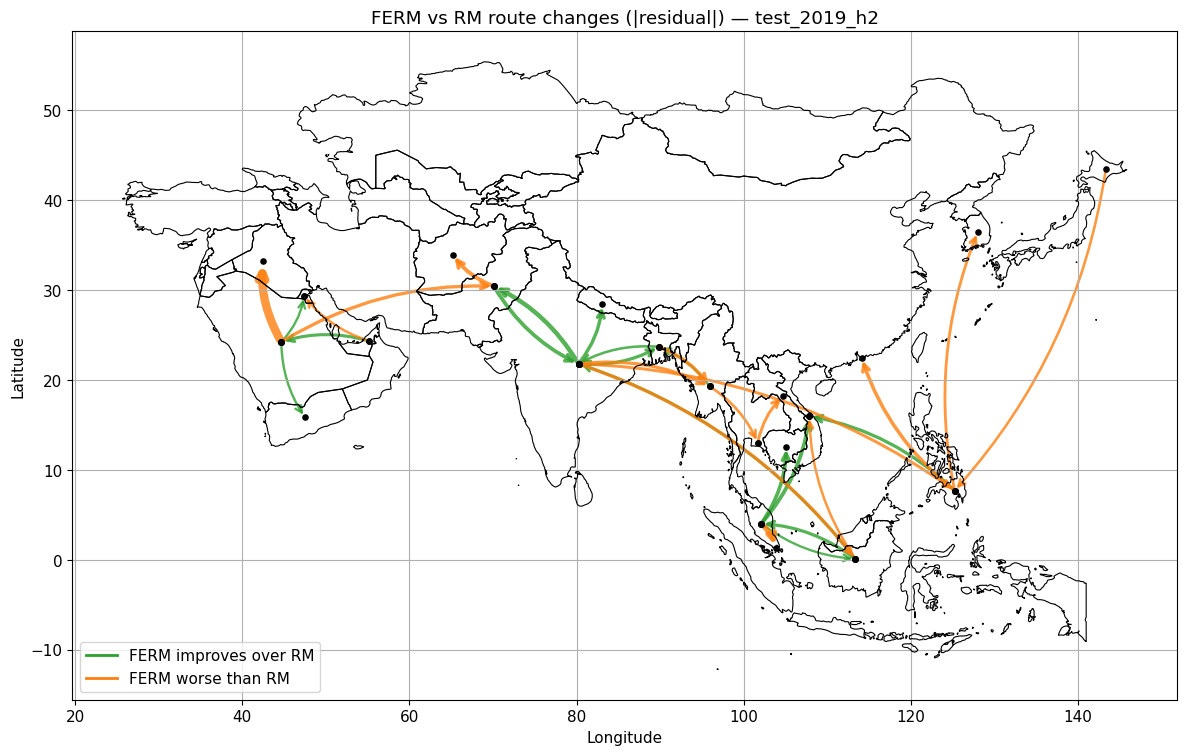

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,predicted_ferm,residual_rm,residual_ferm,improvement_abs_error,improvement_abs_log,route_change
0,IND,PAK,India,Pakistan,0.0,190618.961680,121089.339897,190618.961680,121089.339897,69529.621784,0.197059,Improved
1,MYS,VNM,Malaysia,Vietnam,8967.0,182916.556922,129010.706540,173949.556922,120043.706540,53905.850382,0.151626,Improved
2,PAK,IND,Pakistan,India,0.0,250195.873528,196594.848687,250195.873528,196594.848687,53601.024841,0.104708,Improved
3,MYS,KHM,Malaysia,Cambodia,4257.0,122194.681085,70203.702653,117937.681085,65946.702653,51990.978432,0.240690,Improved
4,IND,NPL,India,Nepal,83188.0,29281.834387,75661.659053,-53906.165613,-7526.340947,46379.824666,0.412268,Improved
5,IND,BGD,India,Bangladesh,26373.0,104134.719837,62457.386222,77761.719837,36084.386222,41677.333615,0.222009,Improved
6,PHL,VNM,Philippines,Vietnam,51624.0,143941.223945,102287.951145,92317.223945,50663.951145,41653.272800,0.148359,Improved
7,IDN,MYS,Indonesia,Malaysia,115531.0,30029.201906,70993.693133,-85501.798094,-44537.306867,40964.491227,0.373668,Improved
8,ARE,SAU,United Arab Emirates,Saudi Arabia,3800.0,81635.462627,42557.945834,77835.462627,38757.945834,39077.516793,0.282893,Improved
9,IDN,IND,Indonesia,India,2323.0,50798.492599,17858.398083,48475.492599,15535.398083,32940.094515,0.453993,Improved


In [63]:
# plot map
from src.ferm.plotting import plot_ferm_vs_rm_route_change_ex

comp_rel = comparisons_relational[only_label]["scaled_sci_2021"]["comparison"].rename(
    {"num_migrants": "total_migrants"}, axis=1
)
plot_ferm_vs_rm_route_change_ex(
    comp_rm,
    comp_abel,
    label=only_label,
    metric="abs_error",
    country_geo=country_geo,
    continent_gdf=continent_gdf,)


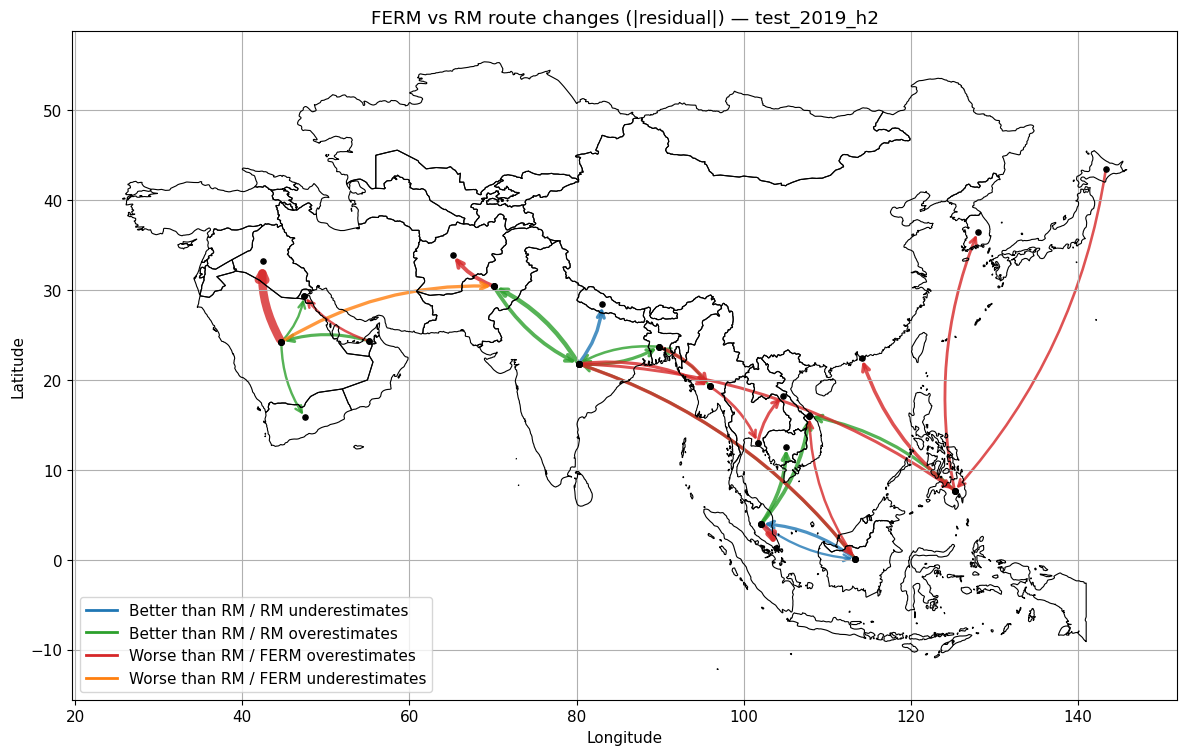

,country_from,country_to,country_from_name,country_to_name,total_migrants,predicted_rm,predicted_ferm,residual_rm,residual_ferm,improvement_abs_error,improvement_abs_log,route_change,route_class
0,IND,PAK,India,Pakistan,0.0,190618.961680,121089.339897,190618.961680,121089.339897,69529.621784,0.197059,Improved,Better / RM overestimates
1,MYS,VNM,Malaysia,Vietnam,8967.0,182916.556922,129010.706540,173949.556922,120043.706540,53905.850382,0.151626,Improved,Better / RM overestimates
2,PAK,IND,Pakistan,India,0.0,250195.873528,196594.848687,250195.873528,196594.848687,53601.024841,0.104708,Improved,Better / RM overestimates
3,MYS,KHM,Malaysia,Cambodia,4257.0,122194.681085,70203.702653,117937.681085,65946.702653,51990.978432,0.240690,Improved,Better / RM overestimates
4,IND,NPL,India,Nepal,83188.0,29281.834387,75661.659053,-53906.165613,-7526.340947,46379.824666,0.412268,Improved,Better / RM underestimates
5,IND,BGD,India,Bangladesh,26373.0,104134.719837,62457.386222,77761.719837,36084.386222,41677.333615,0.222009,Improved,Better / RM overestimates
6,PHL,VNM,Philippines,Vietnam,51624.0,143941.223945,102287.951145,92317.223945,50663.951145,41653.272800,0.148359,Improved,Better / RM overestimates
7,IDN,MYS,Indonesia,Malaysia,115531.0,30029.201906,70993.693133,-85501.798094,-44537.306867,40964.491227,0.373668,Improved,Better / RM underestimates
8,ARE,SAU,United Arab Emirates,Saudi Arabia,3800.0,81635.462627,42557.945834,77835.462627,38757.945834,39077.516793,0.282893,Improved,Better / RM overestimates
9,IDN,IND,Indonesia,India,2323.0,50798.492599,17858.398083,48475.492599,15535.398083,32940.094515,0.453993,Improved,Better / RM overestimates


In [64]:
from src.ferm.plotting import plot_ferm_vs_rm_route_change

plot_ferm_vs_rm_route_change(
    comp_rm,
    comp_abel,
    label=only_label,
    metric="abs_error",
    country_geo=country_geo,
    continent_gdf=continent_gdf,)
